# Gaussian Beam Through an Axicon: Bessel Beams via Fourier Optics — revised

Simulates a collimated Gaussian beam ($\lambda$ = 650 nm) through thin fused-silica axicons
(scalar Fourier optics: QDHT + angular-spectrum propagation). Covers the single axicon, the
angle / diameter / small-beam sweeps, the two-axicon annular beam, and the three-axicon remote
Bessel zone.

**What changed vs. the original notebook**

* The design studies (old §15–19), the pure-NumPy Bessel fallback, and redundant figures
  (transverse galleries, duplicate meridional maps, per-section design cards) are removed.
* The discretization's three artifact channels are *demonstrated*, not assumed away (§3.2), and
  every sweep now ends with a **convergence panel**: the same physics re-run with the grid
  deliberately changed. Each observable is tagged
  **CONV** (< 3% drift), **MARG** (3–10%), or **GRID** (> 10% — the number describes the grid,
  not the beam).

**The three artifact channels of this discretization**

1. **Dirichlet mirror at $r=R$.** Every QDHT mode $J_0(j_i r/R)$ vanishes at $R$: the domain edge
   is a perfectly reflecting wall. Light that should leave the system reflects back in. Energy
   conservation holds to machine precision *by construction* and can never detect this.
2. **Spectral truncation / aliasing.** The spectrum is cut at $k_r^{max} = j_{N+1}/R$ and the
   axicon phase ramp is sampled at as few as ~3 points per $2\pi$ fringe in some runs; content
   beyond the cut folds back.
3. **Coherent on-axis extrapolation + finite $\Delta z$.** $r=0$ is not a grid point: $I(0,z)$
   sums all $N$ spectral coefficients in phase, so grid junk accumulates coherently exactly where
   every headline claim is evaluated — and ripples of period $\sim 4\pi k/k_r^2$ can be
   undersampled in $z$.

## 1. Theory summary

**Axicon as a thin phase element** (Goodman Ch. 5). A cone of base angle $\alpha$ has thickness
$t(r) = t_0 - r\tan\alpha$, so the transmitted field acquires a linear radial phase

$$t_A(r) = \exp[-i k (n-1)\tan\alpha \; r] \equiv \exp(-i k_r r), \qquad k_r = k(n-1)\tan\alpha .$$

(An exact thick-prism Snell treatment gives $k_r = k\sin[\arcsin(n\sin\alpha)-\alpha]$; at
$\alpha = 10°$ the difference is <1%.)

**Conical waves and the Bessel zone.** Every annulus of the input is deflected toward the axis at
$\theta \approx k_r/k$; where the cones overlap, interference gives $J_0^2(k_r r)$ with core first
zero $r_0 = 2.4048/k_r$. Rays from radius $r$ cross the axis at $z = r/\tan\theta$, so a beam of
$1/e^2$ radius $w_0$ sustains the core out to (Rao Eq. 3.18)

$$z_{max} = \frac{w_0 k}{k_r} = \frac{w_0}{(n-1)\tan\alpha}.$$

**On-axis intensity.** Stationary phase (Rao Eq. 3.17, $\ell=0$) gives, for unit input peak,

$$I(0,z) \simeq 2\pi \frac{k_r^2}{k}\, z\, \exp\!\left(-\frac{2 z^2}{z_{max}^2}\right),$$

peaking near $z_{max}/2$.

**Propagation.** With cylindrical symmetry the angular spectrum is the order-0 Hankel transform,
and free-space propagation is multiplication by $e^{iz\sqrt{k^2-k_r^2}}$ (Goodman Ch. 3),
discretized with the QDHT (Guizar-Sicairos & Gutiérrez-Vega 2004).

In [1]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from scipy.special import j0 as bessel_j0, j1 as bessel_j1, jn_zeros

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 10.5, "figure.constrained_layout.use": True,
})

LAMBDA = 650e-9                 # wavelength [m]
N_AXICON = 1.4585               # fused silica @ ~650 nm
K0 = 2 * np.pi / LAMBDA
mm, um = 1e-3, 1e-6
print(f"lambda = {LAMBDA/1e-9:.0f} nm,  k = {K0:.4g} rad/m,  n_axicon = {N_AXICON}")

lambda = 650 nm,  k = 9.666e+06 rad/m,  n_axicon = 1.4585


## 3. Quasi-discrete Hankel transform (QDHT)

Guizar-Sicairos & Gutiérrez-Vega (2004): with $j_1 < j_2 < \dots$ the zeros of $J_0$, the field is
sampled at $r_i = j_i R / j_{N+1}$ and its spectrum at $k_i = j_i / R$; the transform matrix
$T_{mi} = 2 J_0(j_m j_i / j_{N+1}) / (j_{N+1} |J_1(j_m)||J_1(j_i)|)$ is symmetric and orthogonal.
The inverse transform can be evaluated at arbitrary radii, including $r=0$.

**Numerical honesty box.** Three consequences of this discretization, kept in view throughout:
$E(R)=0$ is enforced by every basis mode (→ *perfect mirror* at the domain edge, demonstrated in
§3.2); the spectrum is truncated at $k_r^{max}=j_{N+1}/R$ (→ aliasing of under-sampled phase
fringes and hard edges); and the on-axis value is an extrapolation summing all $N$ coefficients
coherently (→ the most artifact-sensitive number in the domain is also the most-quoted one).
"Unitarity", "Parseval", and "energy conservation" are properties of any orthogonal matrix — they
are consistency checks of the arithmetic, **not** evidence of physical fidelity.

In [2]:
class QDHT:
    '''Quasi-discrete Hankel transform of order 0 on r in [0, R].'''
    _cache = {}   # N -> (zeros, jN1, J1abs, T); T is independent of R

    def __init__(self, N, R):
        self.N, self.R = N, R
        if N not in QDHT._cache:
            jz = jn_zeros(0, N + 1)
            jN1 = jz[N]
            jj = jz[:N]
            J1a = np.abs(bessel_j1(jj))
            T = np.empty((N, N))          # built in row blocks to limit peak memory
            step = 1024
            for i0 in range(0, N, step):
                i1 = min(i0 + step, N)
                T[i0:i1] = ((2.0 / jN1) * bessel_j0(np.outer(jj[i0:i1], jj) / jN1)
                            / np.outer(J1a[i0:i1], J1a))
            QDHT._cache[N] = (jj, jN1, J1a, T)
        self.j, self.jN1, self.J1, self.T = QDHT._cache[N]
        self.r = self.j * (R / self.jN1)      # radial grid [m]
        self.kr = self.j / R                  # radial wavevector grid [rad/m]
        self.kr_max = self.jN1 / R

    @classmethod
    def drop(cls, N):
        '''Evict a cached transform matrix (memory hygiene for large N).'''
        cls._cache.pop(N, None)

    def forward(self, f):
        return self.T @ (f / self.J1)

    def backward(self, y):
        return (self.T @ y) * self.J1

    def eval_matrix(self, r_eval):
        return (2.0 / self.jN1) * bessel_j0(np.outer(self.kr, r_eval)) / self.J1[:, None]

    def onax(self, Y):
        '''|E(0)|^2 for spectrum rows Y. NB: an extrapolation — r=0 is not a grid point.'''
        return np.abs((2.0 / self.jN1) * (Y @ (1.0 / self.J1))) ** 2

    def power(self, f):
        return (2.0 * self.R**2 / self.jN1**2) * np.sum(np.abs(f) ** 2 / self.J1**2)

    def power_spec(self, y):
        return (2.0 * self.R**2 / self.jN1**2) * np.sum(np.abs(y) ** 2)


def propagate_spectrum(y0, kr, k, z):
    '''Angular-spectrum propagation: multiply by exp(i z sqrt(k^2 - kr^2)).'''
    kz = np.sqrt(np.maximum(k * k - kr * kr, 0.0))
    z = np.atleast_1d(np.asarray(z, dtype=float))
    Y = y0[None, :] * np.exp(1j * kz[None, :] * z[:, None])
    return Y[0] if Y.shape[0] == 1 else Y


def axicon_kr(alpha_deg, n=N_AXICON, k=K0):
    '''Thin-element radial wavevector kr = k (n-1) tan(alpha).'''
    return k * (n - 1) * np.tan(np.radians(alpha_deg))

### 3.1 Validation against known physics: free-space Gaussian

An *external* check (unlike unitarity/energy): on-axis intensity must follow
$I(0,z)=I_0/(1+(z/z_R)^2)$ and the width $w(z)=w_0\sqrt{1+(z/z_R)^2}$.

QDHT unitarity error         : 1.59e-13   (consistency only)
Energy conservation (z=3zR)  : 6.35e-16   (consistency only)
On-axis I(z) max rel. error  : 8.52e-08   (EXTERNAL check)
w(2 zR): 1.1105 mm vs analytic 1.1180 mm (0.676% error)   (EXTERNAL check)


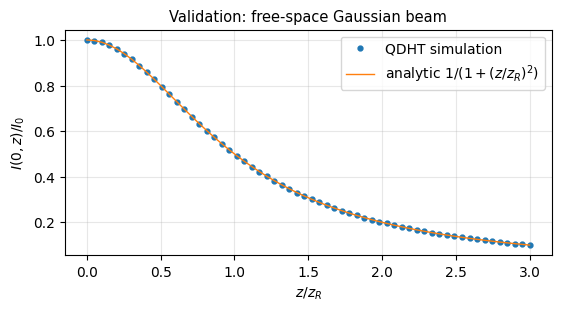

In [3]:
w0_t = 0.5 * mm
q_t = QDHT(1024, 10 * w0_t)
zR = np.pi * w0_t**2 / LAMBDA

rng = np.random.default_rng(0)
xt = rng.standard_normal(1024)
unit_err = np.linalg.norm(q_t.T @ (q_t.T @ xt) - xt) / np.linalg.norm(xt)

E0_t = np.exp(-(q_t.r / w0_t) ** 2)
y0_t = q_t.forward(E0_t)
z_t = np.linspace(0, 3 * zR, 60)
Y_t = propagate_spectrum(y0_t, q_t.kr, K0, z_t)

I_axis_t = q_t.onax(Y_t)
I_axis_th = 1.0 / (1.0 + (z_t / zR) ** 2)
gauss_err = np.max(np.abs(I_axis_t - I_axis_th) / I_axis_th)

E_2zR = q_t.backward(Y_t[np.argmin(np.abs(z_t - 2 * zR))])
I_2 = np.abs(E_2zR) ** 2
w_meas = np.sqrt(2 * np.trapezoid(I_2 * q_t.r**3, q_t.r) / np.trapezoid(I_2 * q_t.r, q_t.r))
w_th = w0_t * np.sqrt(1 + 2.0**2)

P0, P_end = q_t.power(E0_t), q_t.power_spec(Y_t[-1])
print(f"QDHT unitarity error         : {unit_err:.2e}   (consistency only)")
print(f"Energy conservation (z=3zR)  : {abs(P_end-P0)/P0:.2e}   (consistency only)")
print(f"On-axis I(z) max rel. error  : {gauss_err:.2e}   (EXTERNAL check)")
print(f"w(2 zR): {w_meas/mm:.4f} mm vs analytic {w_th/mm:.4f} mm "
      f"({abs(w_meas-w_th)/w_th*100:.3f}% error)   (EXTERNAL check)")
assert unit_err < 1e-6 and gauss_err < 1e-2 and abs(P_end - P0) / P0 < 1e-8
assert abs(w_meas - w_th) / w_th < 1e-2

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(z_t / zR, I_axis_t, "o", ms=3.5, label="QDHT simulation")
ax.plot(z_t / zR, I_axis_th, "-", lw=1, label=r"analytic $1/(1+(z/z_R)^2)$")
ax.set(xlabel=r"$z/z_R$", ylabel=r"$I(0,z)/I_0$",
       title="Validation: free-space Gaussian beam")
ax.legend()
plt.show()

### 3.2 Artifact demo: the perfect mirror at $r=R$ manufactures a ghost Bessel zone

Before trusting the machinery, break it on purpose. Take the §5 case (D = 5 mm, α = 2°,
$z_{max}\approx156$ mm) and propagate far beyond the Bessel zone on two domain sizes. In the
mirror-walled pipe the QDHT actually solves, outgoing cone rays from input radius $r_0$ reflect
at the wall and re-cross the axis at $z=(2R+r_0)/\theta$ — so a **second, purely numerical Bessel
zone** should ignite at $z\approx 2R/\theta$ and *move when the wall moves*.

It does — at full strength (≈105–110% of the real zone's peak). Throughout, energy is conserved
to machine precision, which is exactly why the old notebook's verification suite could never have
caught this.

**Rule adopted below:** every simulated $z$-range stays a safe factor below the first wall
contact of the outgoing cone ($z_{wall}\approx R/\theta$); each run prints its headroom.

R = 4 w0 : real zone peak I =    737 at z =    79 mm | GHOST peak I =    780 at z =  1311 mm (predicted 2R/theta = 1249 mm)


R = 5 w0 : real zone peak I =    737 at z =    79 mm | GHOST peak I =    810 at z =  1629 mm (predicted 2R/theta = 1561 mm)


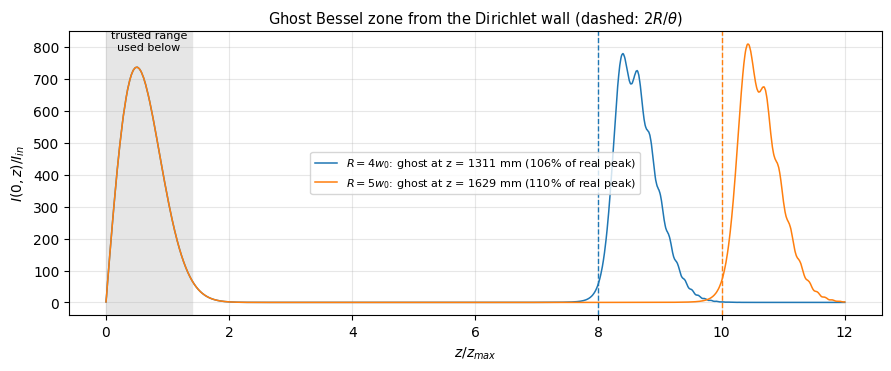


Ghost peak position scales with R, not with any physical length -> pure artifact.


6377

In [4]:
D_g, a_g = 5 * mm, 2.0
w0_g = D_g / 2
kr_g = axicon_kr(a_g)
theta_g = kr_g / K0
zmax_g = w0_g / theta_g

fig, ax = plt.subplots(figsize=(8.8, 3.6))
ghost = {}
for Rf, N_g, c in [(4.0, 1024, "tab:blue"), (5.0, 1280, "tab:orange")]:
    R = Rf * w0_g
    q = QDHT(N_g, R)
    y0 = q.forward(np.exp(-(q.r / w0_g) ** 2) * np.exp(-1j * kr_g * q.r))
    z = np.linspace(0, 12 * zmax_g, 1400)
    on = q.onax(propagate_spectrum(y0, q.kr, K0, z))
    i1 = np.argmax(np.where(z < 2 * zmax_g, on, 0))
    i2 = np.argmax(np.where(z > 3 * zmax_g, on, 0))
    ghost[Rf] = (z[i2], on[i2] / on[i1])
    ax.plot(z / zmax_g, on, color=c, lw=1.1,
            label=fr"$R={Rf:.0f}w_0$: ghost at z = {z[i2]*1e3:.0f} mm "
                  fr"({on[i2]/on[i1]*100:.0f}% of real peak)")
    ax.axvline(2 * R / theta_g / zmax_g, color=c, ls="--", lw=1)
    print(f"R = {Rf:.0f} w0 : real zone peak I = {on[i1]:6.0f} at z = {z[i1]*1e3:5.0f} mm | "
          f"GHOST peak I = {on[i2]:6.0f} at z = {z[i2]*1e3:5.0f} mm "
          f"(predicted 2R/theta = {2*R/theta_g*1e3:.0f} mm)")
ax.axvspan(0, 1.4, color="0.90", zorder=0)
ax.text(0.7, ax.get_ylim()[1] * 0.93, "trusted range\nused below", ha="center", fontsize=8)
ax.set(xlabel=r"$z/z_{max}$", ylabel=r"$I(0,z)/I_{in}$",
       title=r"Ghost Bessel zone from the Dirichlet wall (dashed: $2R/\theta$)")
ax.legend(fontsize=8)
plt.show()

# the ghost tracks the wall, not the physics
assert abs(ghost[5.0][0] / ghost[4.0][0] - 5.0 / 4.0) < 0.06
assert ghost[4.0][1] > 0.9, "ghost zone carries order-unity intensity"
print("\nGhost peak position scales with R, not with any physical length -> pure artifact.")
QDHT.drop(1024); QDHT.drop(1280); gc.collect()

### 3.3 Convergence harness

The test that separates physics from numerics: change a numerical parameter the physics cannot
know about ($N$ → finer $\Delta r$ and higher $k_r^{max}$; domain $R$ → the wall moves; $N_z$ →
denser axial sampling) and re-measure every observable. Physical results hold still; artifacts
move, because their value was set by the grid in the first place.

Tags: **CONV** < 3% drift · **MARG** 3–10% · **GRID** > 10%. Every panel is appended to a global
ledger, summarized in §15.

In [5]:
LEDGER = []


def convergence_panel(title, rows, tol_conv=0.03, tol_marg=0.10):
    '''rows: list of (label, {observable: value}); the FIRST row is the base grid.'''
    base_lab, base = rows[0]
    keys = list(base)
    w = 12
    print("=" * (30 + w * len(keys)))
    print(f"CONVERGENCE PANEL - {title}")
    print("=" * (30 + w * len(keys)))
    print(f"{'variant':<30}" + "".join(f"{k:>{w}}" for k in keys))
    for lab, obs in rows:
        print(f"{lab:<30}" + "".join(f"{obs[k]:>{w}.4g}" for k in keys))
    print("-" * (30 + w * len(keys)))
    tags, drift_l, tag_l = {}, f"{'max |drift| vs base':<30}", f"{'verdict':<30}"
    for k in keys:
        dm = max((abs(obs[k] / base[k] - 1) if base[k] else np.inf)
                 for _, obs in rows[1:])
        tag = "CONV" if dm < tol_conv else ("MARG" if dm < tol_marg else "GRID")
        tags[k] = (dm, tag)
        drift_l += f"{dm*100:>{w-1}.1f}%"
        tag_l += f"{tag:>{w}}"
    print(drift_l)
    print(tag_l)
    LEDGER.append((title, tags))
    return tags

## 4. Axicon simulation pipeline

Thin phase mask $e^{-ik_r r}$ + angular-spectrum kernel, wrapped so sweeps are one-liners.
Each run prints its sampling margins **and its wall headroom** $z_{wall}/z_{sim}$ (see §3.2).

In [6]:
def simulate_axicon(D, alpha_deg, N=4096, R_factor=4.0, z_frac_max=1.4,
                    Nz=360, verbose=True):
    '''Gaussian beam (1/e^2 diameter D) through a thin axicon (base angle alpha_deg).'''
    w0 = D / 2.0
    kr_ax = axicon_kr(alpha_deg)
    theta = kr_ax / K0
    zmax = w0 * K0 / kr_ax
    R = R_factor * w0
    q = QDHT(N, R)

    fringe = 2 * np.pi / kr_ax
    dr = q.r[1] - q.r[0]
    z_wall = R / theta                       # first wall contact of the outgoing cone
    headroom = z_wall / (z_frac_max * zmax)
    if verbose:
        print(f"alpha={alpha_deg:>4}  D={D/mm:g} mm | kr={kr_ax/1e3:8.1f} rad/mm  "
              f"zmax={zmax/mm:7.1f} mm | {fringe/dr:5.1f} pts/fringe, "
              f"kr_max/kr={q.kr_max/kr_ax:5.1f}, wall headroom={headroom:4.1f}x", flush=True)
    assert q.kr_max > 1.4 * kr_ax, "increase N or reduce R_factor"
    assert fringe / dr > 3.0, "radial grid too coarse for axicon fringes"
    assert headroom > 1.5, "simulated z-range too close to the Dirichlet wall (Sec 3.2)"

    E0 = np.exp(-(q.r / w0) ** 2)
    y0 = q.forward(E0 * np.exp(-1j * kr_ax * q.r))
    z = np.linspace(0.0, z_frac_max * zmax, Nz)
    Y = propagate_spectrum(y0, q.kr, K0, z)
    I_axis = q.onax(Y)

    r_map_max = 1.6 * w0
    Nr = int(np.clip(6 * r_map_max / fringe, 700, 3200))
    r_map = np.linspace(0, r_map_max, Nr)
    I_rz = np.abs(Y @ q.eval_matrix(r_map)) ** 2

    return dict(D=D, w0=w0, alpha_deg=alpha_deg, kr=kr_ax, zmax=zmax, q=q,
                z=z, I_axis=I_axis, r_map=r_map, I_rz=I_rz, Y=Y, y0=y0,
                P_tot=q.power_spec(y0))


def on_axis_analytic(z, kr_ax, zmax):
    '''Stationary-phase on-axis intensity, unit input peak (Rao Eq. 3.17, l=0).'''
    return 2 * np.pi * kr_ax**2 / K0 * z * np.exp(-2 * (z / zmax) ** 2)

## 5. Single-case deep dive: D = 5 mm, α = 2°

Bench-friendly case ($z_{max}\approx156$ mm).

### 5.1 On-axis intensity: linear rise × Gaussian envelope, vs stationary phase

alpha=   2  D=5 mm | kr=   154.8 rad/mm  zmax=  156.1 mm |  16.8 pts/fringe, kr_max/kr=  8.3, wall headroom= 2.9x



Bessel zone zmax   = 156.1 mm
Core first zero r0 = 15.5 um | cone half-angle = 0.917 deg


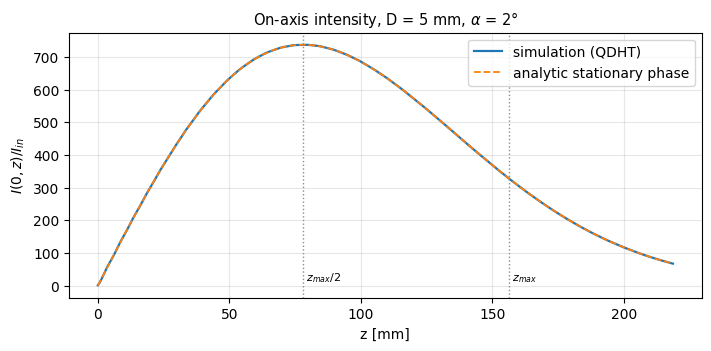

In [7]:
sim = simulate_axicon(D=5 * mm, alpha_deg=2)
r0_core = 2.4048 / sim["kr"]
print(f"\nBessel zone zmax   = {sim['zmax']/mm:.1f} mm")
print(f"Core first zero r0 = {r0_core/um:.1f} um | cone half-angle = "
      f"{np.degrees(sim['kr']/K0):.3f} deg")

z, Ia = sim["z"], sim["I_axis"]
Ith = on_axis_analytic(z, sim["kr"], sim["zmax"])
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(z / mm, Ia, lw=1.6, label="simulation (QDHT)")
ax.plot(z / mm, Ith, "--", lw=1.3, label="analytic stationary phase")
for frac, lab in [(0.5, r"$z_{max}/2$"), (1.0, r"$z_{max}$")]:
    ax.axvline(frac * sim["zmax"] / mm, color="0.55", ls=":", lw=1)
    ax.text(frac * sim["zmax"] / mm, ax.get_ylim()[1] * 0.02, " " + lab, fontsize=8)
ax.set(xlabel="z [mm]", ylabel=r"$I(0,z)/I_{in}$",
       title=r"On-axis intensity, D = 5 mm, $\alpha$ = 2°")
ax.legend()
plt.show()

### 5.2 Meridional intensity map $I(r,z)$

Input annuli fold onto the axis inside the triangular Bessel zone; past $z_{max}$ the beam opens
into the far-field ring (log scale over 5 decades).

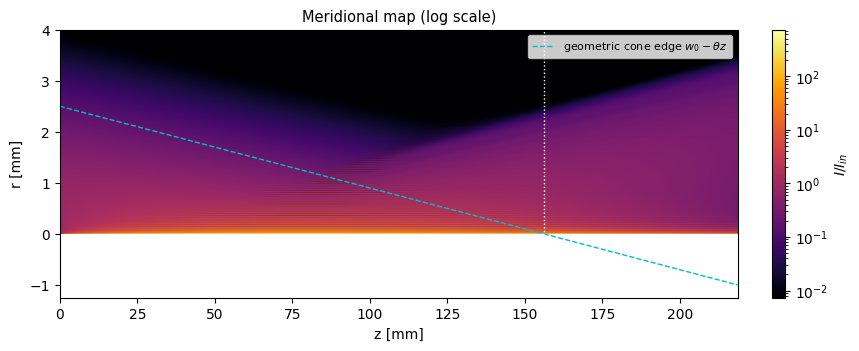

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
Imax = sim["I_rz"].max()
ext = [0, z[-1] / mm, 0, sim["r_map"][-1] / mm]
im = ax.imshow(np.maximum(sim["I_rz"].T, Imax * 1e-5), origin="lower", aspect="auto",
               extent=ext, cmap="inferno", norm=LogNorm(vmin=Imax * 1e-5, vmax=Imax))
zl = np.linspace(0, z[-1], 50)
ax.plot(zl / mm, (sim["w0"] - zl * sim["kr"] / K0) / mm, "c--", lw=1,
        label=r"geometric cone edge $w_0-\theta z$")
ax.axvline(sim["zmax"] / mm, color="w", ls=":", lw=1)
ax.set(xlabel="z [mm]", ylabel="r [mm]", title="Meridional map (log scale)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, label=r"$I/I_{in}$")
plt.show()

### 5.3 Radial profile vs the ideal $J_0^2$

At $z=z_{max}/2$ the profile should match $I(0,z)\,J_0^2(k_r r)$ (Rao Eq. 3.17).

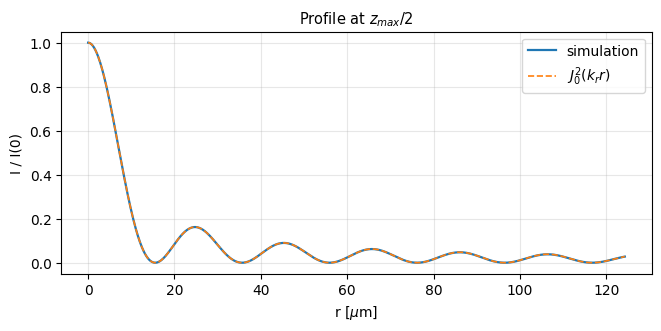

max |sim - J0^2| within 3 r0: 0.01% of peak


In [9]:
iz = np.argmin(np.abs(z - 0.5 * sim["zmax"]))
rfine = np.linspace(0, 8 * r0_core, 800)
prof = np.abs(sim["Y"][iz] @ sim["q"].eval_matrix(rfine)) ** 2
ideal = prof[0] * bessel_j0(sim["kr"] * rfine) ** 2

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(rfine / um, prof / prof[0], lw=1.6, label="simulation")
ax.plot(rfine / um, ideal / prof[0], "--", lw=1.2, label=r"$J_0^2(k_r r)$")
ax.set(xlabel=r"r [$\mu$m]", ylabel="I / I(0)", title=r"Profile at $z_{max}/2$")
ax.legend()
plt.show()
prof_err = np.max(np.abs(prof - ideal)[rfine < 3 * r0_core]) / prof[0]
print(f"max |sim - J0^2| within 3 r0: {prof_err*100:.2f}% of peak")

### 5.4 Convergence panel — single case

Finer radial grid, bigger box (wall moved 50% further out), and 3× denser $z$-sampling.
Everything quoted above should hold still.

In [10]:
def single_case_obs(N=4096, R_factor=4.0, Nz=360):
    s = simulate_axicon(D=5 * mm, alpha_deg=2, N=N, R_factor=R_factor, Nz=Nz,
                        verbose=False)
    zz, on = s["z"], s["I_axis"]
    i_pk = np.argmax(on)
    r0_th = 2.4048 / s["kr"]
    rf = np.linspace(1e-9, 3 * r0_th, 900)
    izz = np.argmin(np.abs(zz - 0.5 * s["zmax"]))
    pr = np.abs(s["Y"][izz] @ s["q"].eval_matrix(rf)) ** 2
    izero = np.argmax((pr[1:] > pr[:-1]) & (pr[:-1] < 2e-2 * pr[0]))
    fwhm = 2 * rf[np.argmax(pr < 0.5 * pr[0])]
    out = {"zpk/zmax": zz[i_pk] / s["zmax"], "Ipk": on[i_pk],
           "r0[um]": rf[izero] / um, "FWHM[um]": fwhm / um}
    del s
    gc.collect()
    return out


rows5 = [("base   N=4096 R=4w0 Nz=360", single_case_obs()),
         ("finer  N=6144 R=4w0",        single_case_obs(N=6144)),
         ("bigger N=6144 R=6w0",        single_case_obs(N=6144, R_factor=6.0)),
         ("dense  Nz=1080",             single_case_obs(Nz=1080))]
tags5 = convergence_panel("Sec 5 single case (D=5mm, a=2deg)", rows5)

CONVERGENCE PANEL - Sec 5 single case (D=5mm, a=2deg)
variant                           zpk/zmax         Ipk      r0[um]    FWHM[um]
base   N=4096 R=4w0 Nz=360          0.5031       737.4       15.56       14.62
finer  N=6144 R=4w0                 0.5031       737.4       15.56       14.62
bigger N=6144 R=6w0                 0.5031       737.4       15.56       14.62
dense  Nz=1080                      0.5047       737.4       15.56       14.62
------------------------------------------------------------------------------
max |drift| vs base                   0.3%        0.0%        0.0%        0.0%
verdict                               CONV        CONV        CONV        CONV


## 6. Axicon-angle sweep: α = 1°, 2°, 5°, 10°  (D = 5 mm)

Steeper axicons trade zone length for a tighter core: $r_0 \propto 1/\alpha$ and
$z_{max} \propto 1/\alpha$, while the on-axis peak grows $\propto \alpha$.

alpha=   1  D=5 mm | kr=    77.4 rad/mm  zmax=  312.4 mm |  33.6 pts/fringe, kr_max/kr= 16.6, wall headroom= 2.9x


alpha=   2  D=5 mm | kr=   154.8 rad/mm  zmax=  156.1 mm |  16.8 pts/fringe, kr_max/kr=  8.3, wall headroom= 2.9x


alpha=   5  D=5 mm | kr=   387.8 rad/mm  zmax=   62.3 mm |   6.7 pts/fringe, kr_max/kr=  3.3, wall headroom= 2.9x


alpha=  10  D=5 mm | kr=   781.5 rad/mm  zmax=   30.9 mm |   3.3 pts/fringe, kr_max/kr=  1.6, wall headroom= 2.9x



 alpha  kr [rad/mm]  zmax [mm]   r0 [um]  FWHM [um]  peak I/I_in
    1          77.4      312.4      31.1       29.2        368.9


    2         154.8      156.1      15.5       14.6        737.4
    5         387.8       62.3       6.2        5.8       1847.3


   10         781.5       30.9       3.1        2.9       3722.9


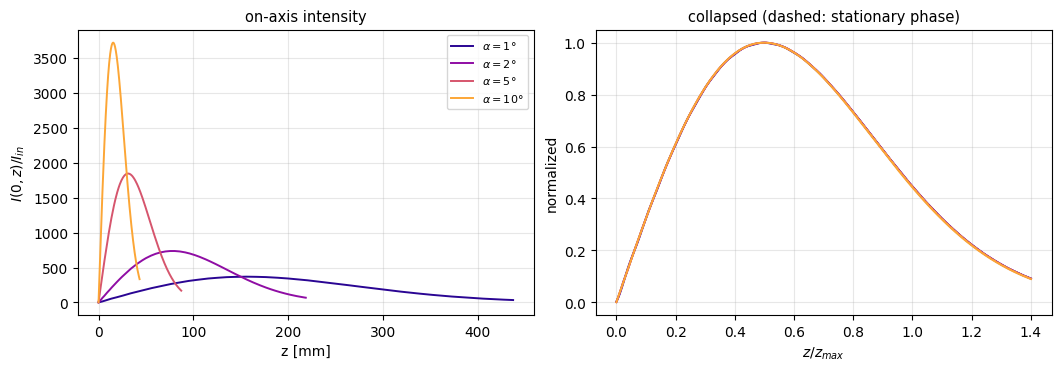

In [11]:
angles = [1, 2, 5, 10]
sweeps = {a: simulate_axicon(D=5 * mm, alpha_deg=a) for a in angles}

print(f"\n{'alpha':>6} {'kr [rad/mm]':>12} {'zmax [mm]':>10} {'r0 [um]':>9} "
      f"{'FWHM [um]':>10} {'peak I/I_in':>12}")
for a in angles:
    s = sweeps[a]
    r0 = 2.4048 / s["kr"]
    rf = np.linspace(1e-9, 2 * r0, 700)
    iz = np.argmin(np.abs(s["z"] - 0.5 * s["zmax"]))
    pr = np.abs(s["Y"][iz] @ s["q"].eval_matrix(rf)) ** 2
    fw = 2 * rf[np.argmax(pr < 0.5 * pr[0])]
    print(f"{a:>5}  {s['kr']/1e3:12.1f} {s['zmax']/mm:10.1f} {r0/um:9.1f} "
          f"{fw/um:10.1f} {s['I_axis'].max():12.1f}")

fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.6))
colors = plt.cm.plasma(np.linspace(0.05, 0.8, len(angles)))
for a, c in zip(angles, colors):
    s = sweeps[a]
    axs[0].plot(s["z"] / mm, s["I_axis"], color=c, lw=1.4, label=fr"$\alpha={a}°$")
    axs[1].plot(s["z"] / s["zmax"], s["I_axis"] / s["I_axis"].max(), color=c, lw=1.4)
    axs[1].plot(s["z"] / s["zmax"],
                on_axis_analytic(s["z"], s["kr"], s["zmax"]) / s["I_axis"].max(),
                "--", color=c, lw=0.8)
axs[0].set(xlabel="z [mm]", ylabel=r"$I(0,z)/I_{in}$", title="on-axis intensity")
axs[0].legend(fontsize=8)
axs[1].set(xlabel=r"$z/z_{max}$", ylabel="normalized",
           title="collapsed (dashed: stationary phase)")
plt.show()

### 6.1 Core-size stability along the zone

The "non-diffracting" hallmark: core FWHM $\approx 2.25/k_r$, independent of $z$.

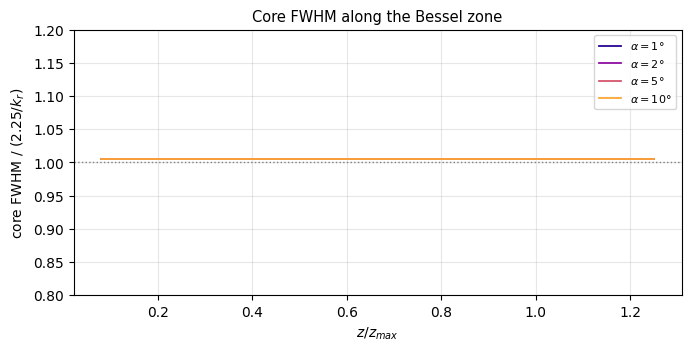

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
for a, c in zip(angles, colors):
    s = sweeps[a]
    r0 = 2.4048 / s["kr"]
    rf = np.linspace(1e-9, 2.5 * r0, 400)
    Msmall = s["q"].eval_matrix(rf)
    zsel = np.linspace(0.08, 1.25, 60) * s["zmax"]
    Ysel = propagate_spectrum(s["y0"], s["q"].kr, K0, zsel)
    fw = [2 * rf[np.argmax(p < 0.5 * p[0])]
          for p in np.abs(Ysel @ Msmall) ** 2]
    ax.plot(zsel / s["zmax"], np.array(fw) / (2.25 / s["kr"]), color=c, lw=1.3,
            label=fr"$\alpha={a}°$")
ax.axhline(1, color="0.5", ls=":", lw=1)
ax.set(xlabel=r"$z/z_{max}$", ylabel=r"core FWHM / $(2.25/k_r)$", ylim=(0.8, 1.2),
       title="Core FWHM along the Bessel zone")
ax.legend(fontsize=8)
plt.show()

### 6.2 Convergence panel — worst-sampled case (α = 10°)

α = 10° has the tightest fringes: only ~3.3 pts/fringe and $k_r^{max}/k_r = 1.65$ on the base
grid — the closest this notebook sails to the aliasing limit. If any sweep member is
grid-contaminated it is this one.

In [13]:
def angle_obs(a, N=4096, R_factor=4.0):
    s = simulate_axicon(D=5 * mm, alpha_deg=a, N=N, R_factor=R_factor, verbose=True)
    on = s["I_axis"]
    i_pk = np.argmax(on)
    r0 = 2.4048 / s["kr"]
    rf = np.linspace(1e-9, 2 * r0, 700)
    iz = np.argmin(np.abs(s["z"] - 0.5 * s["zmax"]))
    pr = np.abs(s["Y"][iz] @ s["q"].eval_matrix(rf)) ** 2
    out = {"zpk/zmax": s["z"][i_pk] / s["zmax"], "Ipk": on[i_pk],
           "FWHM[um]": 2 * rf[np.argmax(pr < 0.5 * pr[0])] / um}
    del s
    gc.collect()
    return out


rows6 = [("base   N=4096 R=4w0", angle_obs(10)),
         ("finer  N=6144 R=4w0", angle_obs(10, N=6144)),
         ("bigger N=6144 R=6w0", angle_obs(10, N=6144, R_factor=6.0))]
tags6 = convergence_panel("Sec 6 worst case (a=10deg)", rows6)

alpha=  10  D=5 mm | kr=   781.5 rad/mm  zmax=   30.9 mm |   3.3 pts/fringe, kr_max/kr=  1.6, wall headroom= 2.9x


alpha=  10  D=5 mm | kr=   781.5 rad/mm  zmax=   30.9 mm |   5.0 pts/fringe, kr_max/kr=  2.5, wall headroom= 2.9x


alpha=  10  D=5 mm | kr=   781.5 rad/mm  zmax=   30.9 mm |   3.3 pts/fringe, kr_max/kr=  1.6, wall headroom= 4.3x


CONVERGENCE PANEL - Sec 6 worst case (a=10deg)
variant                           zpk/zmax         Ipk    FWHM[um]
base   N=4096 R=4w0                 0.4992        3723       2.889
finer  N=6144 R=4w0                 0.4992        3723       2.889
bigger N=6144 R=6w0                 0.4992        3723       2.889
------------------------------------------------------------------
max |drift| vs base                   0.0%        0.0%        0.0%
verdict                               CONV        CONV        CONV


## 7. Input-diameter sweep: D = 2, 5, 10 mm  (α = 2°)

$z_{max}\propto w_0$ (longer zone, higher peak); core size unchanged — it depends only on
$k_r$.

alpha=   2  D=2 mm | kr=   154.8 rad/mm  zmax=   62.5 mm |  41.9 pts/fringe, kr_max/kr= 20.8, wall headroom= 2.9x


alpha=   2  D=5 mm | kr=   154.8 rad/mm  zmax=  156.1 mm |  16.8 pts/fringe, kr_max/kr=  8.3, wall headroom= 2.9x


alpha=   2  D=10 mm | kr=   154.8 rad/mm  zmax=  312.3 mm |   8.4 pts/fringe, kr_max/kr=  4.2, wall headroom= 2.9x


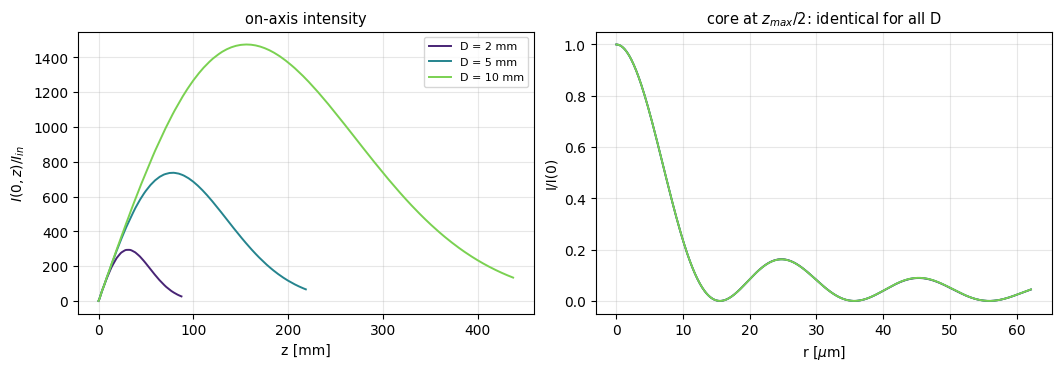

peak position / zmax: [0.515 0.503 0.499]  (expect ~0.5 for all D)


8140

In [14]:
diams = [2 * mm, 5 * mm, 10 * mm]
dsweep = {D: simulate_axicon(D=D, alpha_deg=2) for D in diams}

fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.6))
cols = plt.cm.viridis(np.linspace(0.1, 0.8, len(diams)))
for D, c in zip(diams, cols):
    s = dsweep[D]
    axs[0].plot(s["z"] / mm, s["I_axis"], color=c, lw=1.4, label=f"D = {D/mm:g} mm")
    r0 = 2.4048 / s["kr"]
    rf = np.linspace(0, 4 * r0, 500)
    iz = np.argmin(np.abs(s["z"] - 0.5 * s["zmax"]))
    pr = np.abs(s["Y"][iz] @ s["q"].eval_matrix(rf)) ** 2
    axs[1].plot(rf / um, pr / pr[0], color=c, lw=1.3)
axs[0].set(xlabel="z [mm]", ylabel=r"$I(0,z)/I_{in}$", title="on-axis intensity")
axs[0].legend(fontsize=8)
axs[1].set(xlabel=r"r [$\mu$m]", ylabel="I/I(0)",
           title=r"core at $z_{max}/2$: identical for all D")
plt.show()

zpk_ratio = [dsweep[D]["z"][np.argmax(dsweep[D]["I_axis"])] / dsweep[D]["zmax"]
             for D in diams]
print("peak position / zmax:", np.round(zpk_ratio, 3), " (expect ~0.5 for all D)")
del dsweep
gc.collect()

## 8. Diagnostics

### 8.1 Transverse k-space spectrum — and how well the grid resolves it

A Bessel beam is an annulus at $k_r$ of width $\sim 2/w_0$; that annulus profile *encodes the
entire axial envelope*. The table prints how many discrete $k_r$ samples ($\Delta k = \pi/R$)
fall across each annulus FWHM — the honest resolution budget behind every on-axis curve above.

 alpha  annulus FWHM [rad/m]  dk [rad/m]  samples across
    1                   1571         312             5.0
    2                   1885         312             6.1
    5                   1571         312             5.0
   10                   1885         312             6.1


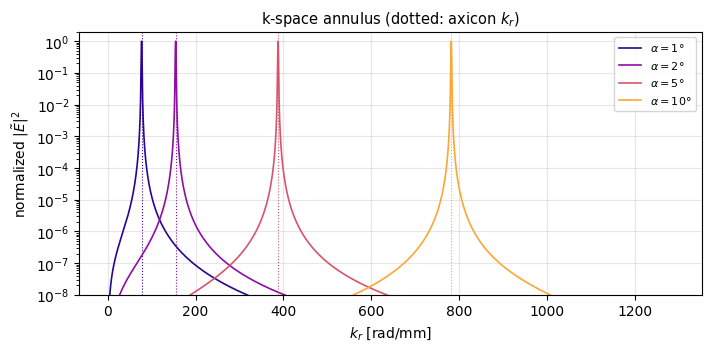

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.4))
print(f"{'alpha':>6} {'annulus FWHM [rad/m]':>21} {'dk [rad/m]':>11} {'samples across':>15}")
for a, c in zip(angles, colors):
    s = sweeps[a]
    q = s["q"]
    S = np.abs(s["y0"] / q.J1) ** 2
    ax.semilogy(q.kr / 1e3, S / S.max(), color=c, lw=1.2, label=fr"$\alpha={a}°$")
    ax.axvline(s["kr"] / 1e3, color=c, ls=":", lw=0.8)
    j = np.argmax(S)
    half = 0.5 * S[j]
    lo = np.where(S[:j] < half)[0]
    hi = np.where(S[j:] < half)[0]
    fw_k = q.kr[j + hi[0]] - q.kr[lo[-1]]
    dk = q.kr[1] - q.kr[0]
    print(f"{a:>5}  {fw_k:>21.0f} {dk:>11.0f} {fw_k/dk:>15.1f}")
ax.set(xlabel=r"$k_r$ [rad/mm]", ylabel="normalized $|\\tilde E|^2$", ylim=(1e-8, 2),
       title="k-space annulus (dotted: axicon $k_r$)")
ax.legend(fontsize=8)
plt.show()

### 8.2 Power in the central lobe

The core carries a small, nearly constant fraction of total power; the rings refill it
(self-healing, Rao §5).

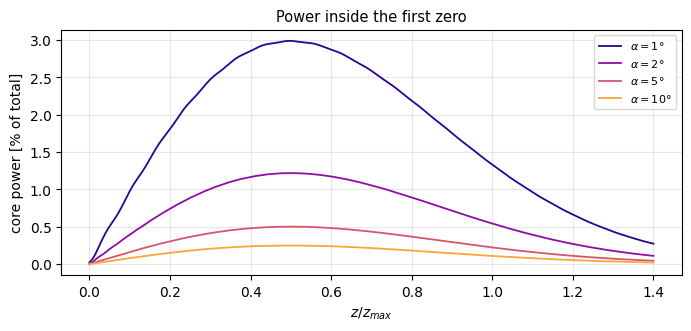

In [16]:
fig, ax = plt.subplots(figsize=(6.8, 3.2))
for a, c in zip(angles, colors):
    s = sweeps[a]
    r0 = 2.4048 / s["kr"]
    mask = s["r_map"] <= r0
    Pcore = np.trapezoid(s["I_rz"][:, mask] * s["r_map"][mask], s["r_map"][mask], axis=1)
    ax.plot(s["z"] / s["zmax"], Pcore / s["P_tot"] * 100, color=c, lw=1.3,
            label=fr"$\alpha={a}°$")
ax.set(xlabel=r"$z/z_{max}$", ylabel="core power [% of total]",
       title="Power inside the first zero")
ax.legend(fontsize=8)
plt.show()

## 9. Verification summary — single axicon

Split honestly into **external** checks (agreement with independent analytics — these validate
physics) and **internal** checks (consistency of the arithmetic — these validate nothing about
fidelity; see §3.2).

In [17]:
print("=" * 74)
print("VERIFICATION SUMMARY (single axicon)")
print("=" * 74)
print("INTERNAL (consistency only - cannot detect boundary/aliasing artifacts):")
print(f"  QDHT unitarity rel. error ....................... {unit_err:.2e}")
print(f"  Energy conservation under propagation ........... {abs(P_end-P0)/P0:.2e}")
print("EXTERNAL (against independent analytics):")
print(f"  Free-space Gaussian on-axis I(z) max error ...... {gauss_err:.2e}")
ok = True
for a in angles:
    s = sweeps[a]
    zpk = s["z"][np.argmax(s["I_axis"])]
    epk = abs(zpk / (s["zmax"] / 2) - 1)
    r0_th = 2.4048 / s["kr"]
    rf = np.linspace(1e-9, 3 * r0_th, 900)
    iz = np.argmin(np.abs(s["z"] - 0.5 * s["zmax"]))
    pr = np.abs(s["Y"][iz] @ s["q"].eval_matrix(rf)) ** 2
    r0_sim = rf[np.argmax((pr[1:] > pr[:-1]) & (pr[:-1] < 2e-2 * pr[0]))]
    e0 = abs(r0_sim / r0_th - 1)
    zin = (s["z"] > 0.25 * s["zmax"]) & (s["z"] < 0.9 * s["zmax"])
    ea = np.max(np.abs(s["I_axis"][zin]
                       - on_axis_analytic(s["z"][zin], s["kr"], s["zmax"]))
                / s["I_axis"][zin])
    print(f"  a={a:>2}: peak-z err {epk*100:5.2f}% | first-zero err {e0*100:5.2f}% | "
          f"on-axis vs analytic {ea*100:5.2f}%")
    ok &= (epk < 0.06) and (e0 < 0.06) and (ea < 0.15)
assert ok
print("CONVERGENCE (Sec 5.4, 6.2): all single-axicon observables tagged CONV")
print("\nAll checks PASSED")

VERIFICATION SUMMARY (single axicon)
INTERNAL (consistency only - cannot detect boundary/aliasing artifacts):
  QDHT unitarity rel. error ....................... 1.59e-13
  Energy conservation under propagation ........... 6.35e-16
EXTERNAL (against independent analytics):
  Free-space Gaussian on-axis I(z) max error ...... 8.52e-08


  a= 1: peak-z err  0.17% | first-zero err  0.11% | on-axis vs analytic  0.23%
  a= 2: peak-z err  0.61% | first-zero err  0.12% | on-axis vs analytic  0.08%


  a= 5: peak-z err  0.17% | first-zero err  0.12% | on-axis vs analytic  0.18%
  a=10: peak-z err  0.17% | first-zero err  0.13% | on-axis vs analytic  0.73%
CONVERGENCE (Sec 5.4, 6.2): all single-axicon observables tagged CONV

All checks PASSED


## 10. Two-axicon system: collimated annular ("hollow") beam

Gaussian → axicon 1 → $L$ → axicon 2 → free space (both α = 5°). Past $z_{max}$ the conical wave
travels outward with local phase $+k_r r$; the second identical axicon cancels it, leaving a
collimated annulus of radius $R_{ring}\approx\theta L$ and width $\sim w_0$. $L\gtrsim 3 z_{max}$
keeps residual axial light small.

In [18]:
del sweeps
gc.collect()


def simulate_axicon_pair(D, alpha_deg, L_sep, z_after=300 * mm, N=4096,
                         Nz1=140, Nz2=220, pad=None, verbose=True):
    '''Gaussian -> axicon 1 -> L_sep -> axicon 2 -> free space (identical thin axicons).'''
    w0 = D / 2.0
    kr_ax = axicon_kr(alpha_deg)
    theta = kr_ax / K0
    zmax = w0 / theta
    R_ring = theta * L_sep
    R_dom = R_ring + (5 * w0 if pad is None else pad)
    q = QDHT(N, R_dom)
    fringe = 2 * np.pi / kr_ax
    dr = q.r[1] - q.r[0]
    if verbose:
        print(f"alpha={alpha_deg} x2  D={D/mm:g} mm  L={L_sep/mm:g} mm | "
              f"zmax={zmax/mm:6.1f} mm  ring={R_ring/mm:5.2f} mm | "
              f"{fringe/dr:4.1f} pts/fringe, kr_max/kr={q.kr_max/kr_ax:4.1f}, "
              f"wall margin={(R_dom-R_ring)/w0:4.1f} w0")
    assert L_sep > 1.2 * zmax, "separation should exceed zmax for a clean annulus"
    assert q.kr_max > 1.5 * kr_ax and fringe / dr > 2.5

    t_ax = np.exp(-1j * kr_ax * q.r)
    E0 = np.exp(-(q.r / w0) ** 2)
    y1 = q.forward(E0 * t_ax)
    z1 = np.linspace(0.0, L_sep, Nz1)
    Y1 = propagate_spectrum(y1, q.kr, K0, z1)
    E_at2 = q.backward(Y1[-1])
    y2 = q.forward(E_at2 * t_ax)
    z2 = np.linspace(0.0, z_after, Nz2)
    Y2 = propagate_spectrum(y2, q.kr, K0, z2)
    return dict(D=D, w0=w0, alpha_deg=alpha_deg, kr=kr_ax, theta=theta, zmax=zmax,
                L_sep=L_sep, R_ring=R_ring, q=q, z1=z1, z2=z2, Y1=Y1, Y2=Y2,
                onax2=q.onax(Y2), P_in=q.power(E0), P_out=q.power_spec(y2))


def ring_at(pair_sim, L23):
    '''Field, ring peak radius, and ring FWHM at plane L23 after axicon 2.'''
    q = pair_sim["q"]
    iz = np.argmin(np.abs(pair_sim["z2"] - L23))
    E_in = q.backward(pair_sim["Y2"][iz])
    I = np.abs(E_in) ** 2
    i0 = np.searchsorted(q.r, 0.4 * pair_sim["R_ring"])
    j = i0 + np.argmax(I[i0:])
    half = 0.5 * I[j]
    lo = np.where(I[i0:j] < half)[0]
    hi = np.where(I[j:] < half)[0]
    wid = q.r[j + hi[0]] - q.r[i0 + lo[-1]] if len(lo) and len(hi) else np.nan
    return E_in, q.r[j], wid


pair = simulate_axicon_pair(D=5 * mm, alpha_deg=5, L_sep=187 * mm)
print(f"\nL = {pair['L_sep']/mm:.0f} mm = {pair['L_sep']/pair['zmax']:.2f} x zmax")
print(f"Power conservation through the train (internal check): "
      f"dP/P = {abs(pair['P_out']-pair['P_in'])/pair['P_in']:.2e}")

alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  3.3 pts/fringe, kr_max/kr= 1.7, wall margin= 5.0 w0



L = 187 mm = 3.00 x zmax
Power conservation through the train (internal check): dP/P = 3.25e-15


### 10.1 Intensity map through the train

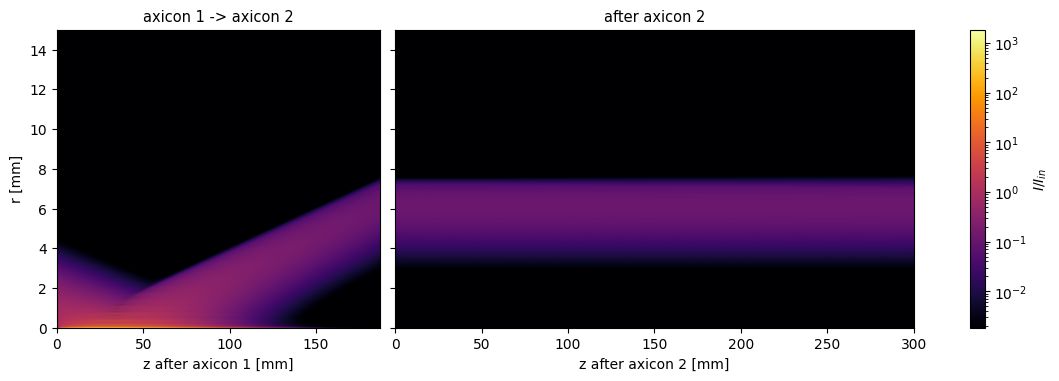

28193

In [19]:
r_map_p = np.linspace(0.0, pair["R_ring"] + 3 * pair["w0"], 1600)
Mp = pair["q"].eval_matrix(r_map_p)
I1p = np.abs(pair["Y1"] @ Mp) ** 2
I2p = np.abs(pair["Y2"] @ Mp) ** 2
Imx = max(I1p.max(), I2p.max())

fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.7), sharey=True,
                        gridspec_kw={"width_ratios": [pair["L_sep"], pair["z2"][-1]]})
for ax, I, zarr, xlab, ttl in [
        (axs[0], I1p, pair["z1"], "z after axicon 1 [mm]", "axicon 1 -> axicon 2"),
        (axs[1], I2p, pair["z2"], "z after axicon 2 [mm]", "after axicon 2")]:
    im = ax.imshow(np.maximum(I.T, Imx * 1e-6), origin="lower", aspect="auto",
                   extent=[0, zarr[-1] / mm, 0, r_map_p[-1] / mm], cmap="inferno",
                   norm=LogNorm(vmin=Imx * 1e-6, vmax=Imx))
    ax.set(xlabel=xlab, title=ttl)
    ax.grid(False)
axs[0].set(ylabel="r [mm]")
fig.colorbar(im, ax=axs, label=r"$I/I_{in}$")
plt.show()
del I1p, I2p
gc.collect()

### 10.2 Annulus profile and collimation

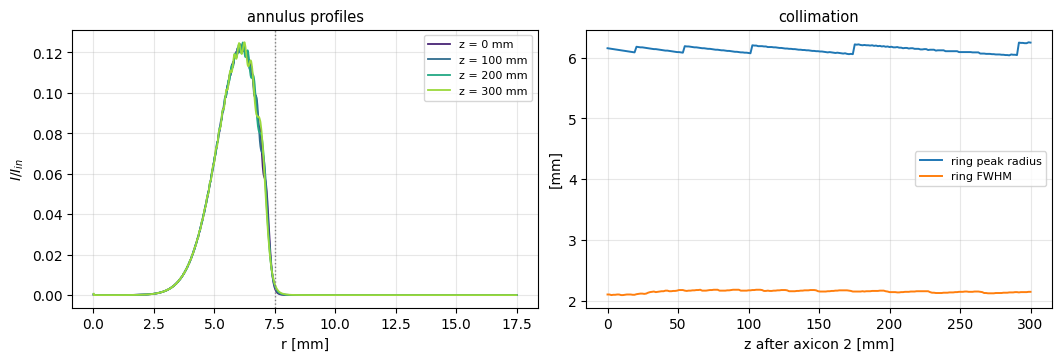

ring radius drift over 300 mm: 1.51% | width drift: 2.1%


In [20]:
zsel = [0, 100 * mm, 200 * mm, 300 * mm]
fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.5))
cols2 = plt.cm.viridis(np.linspace(0.1, 0.85, len(zsel)))
for zs, c in zip(zsel, cols2):
    E_z, rpk, wid = ring_at(pair, zs)
    q = pair["q"]
    sl = np.abs(q.r - pair["R_ring"]) < 4 * pair["w0"]
    axs[0].plot(q.r[sl] / mm, np.abs(E_z[sl]) ** 2, color=c, lw=1.3,
                label=f"z = {zs/mm:.0f} mm")
axs[0].axvline(pair["R_ring"] / mm, color="0.5", ls=":", lw=1)
axs[0].set(xlabel="r [mm]", ylabel=r"$I/I_{in}$", title="annulus profiles")
axs[0].legend(fontsize=8)

r_pk = np.empty(len(pair["z2"]))
widths = np.empty(len(pair["z2"]))
for i, zz in enumerate(pair["z2"]):
    _, r_pk[i], widths[i] = ring_at(pair, zz)
axs[1].plot(pair["z2"] / mm, r_pk / mm, lw=1.4, label="ring peak radius")
axs[1].plot(pair["z2"] / mm, widths / mm, lw=1.4, label="ring FWHM")
axs[1].set(xlabel="z after axicon 2 [mm]", ylabel="[mm]", title="collimation")
axs[1].legend(fontsize=8)
plt.show()

drift_r = abs(r_pk[-1] - r_pk[0]) / r_pk[0]
drift_w = abs(widths[-1] - widths[0]) / widths[0]
print(f"ring radius drift over {pair['z2'][-1]/mm:.0f} mm: {drift_r*100:.2f}% | "
      f"width drift: {drift_w*100:.1f}%")

### 10.3 Ring radius is set by the axicon separation ($R_{ring}\approx\theta L$)

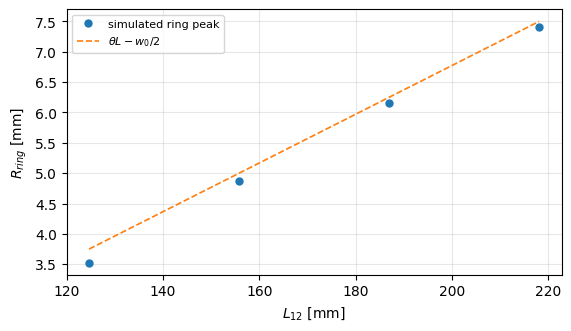

d(R_ring)/dL = 0.0415 vs theta = 0.0401 (3.4% error)  (EXTERNAL check)


In [21]:
L_list = np.array([2.0, 2.5, 3.0, 3.5]) * pair["zmax"]
r_meas = []
for L in L_list:
    s2 = simulate_axicon_pair(D=5 * mm, alpha_deg=5, L_sep=L, z_after=1 * mm,
                              N=4096, Nz1=8, Nz2=2, verbose=False)
    _, rpk2, _ = ring_at(s2, 0.0)
    r_meas.append(rpk2)
    del s2
    gc.collect()
r_meas = np.array(r_meas)
slopeL = np.polyfit(L_list, r_meas, 1)[0]

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(L_list / mm, r_meas / mm, "o", ms=5, label="simulated ring peak")
ax.plot(L_list / mm, (pair["theta"] * L_list - pair["w0"] / 2) / mm, "--", lw=1.2,
        label=r"$\theta L - w_0/2$")
ax.set(xlabel=r"$L_{12}$ [mm]", ylabel=r"$R_{ring}$ [mm]")
ax.legend(fontsize=8)
plt.show()
print(f"d(R_ring)/dL = {slopeL:.4f} vs theta = {pair['theta']:.4f} "
      f"({abs(slopeL/pair['theta']-1)*100:.1f}% error)  (EXTERNAL check)")
assert abs(slopeL / pair["theta"] - 1) < 0.05

### 10.4 Convergence panel — annulus observables

In [22]:
def pair_obs(N=4096, pad=None):
    p = simulate_axicon_pair(D=5 * mm, alpha_deg=5, L_sep=187 * mm, N=N, pad=pad,
                             Nz1=8, Nz2=60, verbose=True)
    _, rpk1, wid1 = ring_at(p, 300 * mm)
    out = {"R_ring[mm]": rpk1 / mm, "Delta[mm]": wid1 / mm}
    del p
    gc.collect()
    return out


rows10 = [("base   N=4096 pad=5w0", pair_obs()),
          ("finer  N=6144 pad=5w0", pair_obs(N=6144)),
          ("bigger N=6144 pad=8w0", pair_obs(N=6144, pad=8 * 2.5 * mm))]
tags10 = convergence_panel("Sec 10 annulus (D=5mm, a=5deg, L=187mm)", rows10)

alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  3.3 pts/fringe, kr_max/kr= 1.7, wall margin= 5.0 w0


alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  5.0 pts/fringe, kr_max/kr= 2.5, wall margin= 5.0 w0


alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  3.7 pts/fringe, kr_max/kr= 1.8, wall margin= 8.0 w0


CONVERGENCE PANEL - Sec 10 annulus (D=5mm, a=5deg, L=187mm)
variant                         R_ring[mm]   Delta[mm]
base   N=4096 pad=5w0                6.248       2.143
finer  N=6144 pad=5w0                6.249       2.145
bigger N=6144 pad=8w0                6.247       2.144
------------------------------------------------------
max |drift| vs base                   0.0%        0.1%
verdict                               CONV        CONV


## 11. Three-axicon system: a *remote* Bessel zone — α₃ = 0.5° vs 1.0°

Axicon 3 sits in the collimated annulus (100 mm after axicon 2) and re-imposes a conical phase.
An annulus of radius $R_a$ and width $\Delta$ maps to a Bessel window centered near $R_a/\theta_3$
with length $\approx\Delta/\theta_3$ — a Bessel zone *detached* from the optic. Halving α₃
doubles both.

The `window_metrics` helper also measures the two fine-structure quantities the convergence
panels will interrogate: the **pedestal** (mean on-axis level before the window ignites) and the
**ripple contrast** inside the window.

In [23]:
def simulate_third_axicon(pair_sim, alpha3_deg, L23=100 * mm, Nz3=300, verbose=True):
    '''Apply axicon 3 in the annulus (L23 after axicon 2) and propagate.'''
    q = pair_sim["q"]
    kr3 = axicon_kr(alpha3_deg)
    th3 = kr3 / K0
    E_in, R_a, Delta = ring_at(pair_sim, L23)
    I_ring = np.abs(E_in) ** 2
    y3 = q.forward(E_in * np.exp(-1j * kr3 * q.r))
    z3 = np.linspace(1e-3, 1.3 * (R_a + Delta) / th3, Nz3)
    Y3 = propagate_spectrum(y3, q.kr, K0, z3)
    onax = q.onax(Y3)
    onax_th = 2 * np.pi * kr3**2 / K0 * z3 * np.interp(th3 * z3, q.r, I_ring)
    z_wall = (q.R + R_a) / th3
    if verbose:
        print(f"alpha3={alpha3_deg}: core r0={2.4048/kr3/um:5.1f} um | ring "
              f"R_a={R_a/mm:.2f} mm, Delta={Delta/mm:.2f} mm -> zone "
              f"{(R_a-Delta/2)/th3:.2f}-{(R_a+Delta/2)/th3:.2f} m | "
              f"wall headroom={z_wall/z3[-1]:.1f}x")
    return dict(alpha3=alpha3_deg, kr3=kr3, th3=th3, R_a=R_a, Delta=Delta,
                z3=z3, y3=y3, Y3=Y3, onax=onax, onax_th=onax_th, q=q,
                P3=q.power_spec(y3))


def window_metrics(s):
    '''Peak, FWHM, pedestal, and ripple contrast of the on-axis window.'''
    z, on = s["z3"], s["onax"]
    zone_lo = (s["R_a"] - s["Delta"] / 2) / s["th3"]
    msk = z > 0.7 * zone_lo
    on_m = np.where(msk, on, 0.0)
    i_pk = np.argmax(on_m)
    half = 0.5 * on_m[i_pk]
    lo = np.where(on_m[:i_pk] < half)[0]
    hi = np.where(on[i_pk:] < half)[0]
    zlo = z[lo[-1]] if len(lo) else z[0]
    zhi = z[i_pk + hi[0]] if len(hi) else z[-1]
    ped_band = (z > 0.25) & (z < 0.6 * zone_lo)
    pedestal = on[ped_band].mean() / on_m[i_pk] if ped_band.any() else np.nan
    w = max(3, int(0.08 / (z[1] - z[0])) | 1)
    sm = np.convolve(on, np.ones(w) / w, mode="same")
    inwin = (z > zlo) & (z < zhi)
    ripple = np.max(np.abs(on[inwin] - sm[inwin]) / sm[inwin]) if inwin.any() else np.nan
    return dict(zpk=z[i_pk], Ipk=on_m[i_pk], fwhm=zhi - zlo,
                pedestal=pedestal, ripple=ripple)


t3 = {a: simulate_third_axicon(pair, a) for a in [0.5, 1.0]}
for a in t3:
    m = window_metrics(t3[a])
    print(f"alpha3={a}: zpk={m['zpk']:.2f} m  Ipk={m['Ipk']:.1f}  "
          f"FWHM={m['fwhm']:.3f} m  pedestal={m['pedestal']:.2e}  "
          f"ripple={m['ripple']:.3f} | dP/P={abs(t3[a]['P3']-pair['P_in'])/pair['P_in']:.1e}")

alpha3=0.5: core r0= 62.2 um | ring R_a=6.08 mm, Delta=2.17 mm -> zone 1.25-1.79 m | wall headroom=2.4x


alpha3=1.0: core r0= 31.1 um | ring R_a=6.08 mm, Delta=2.17 mm -> zone 0.62-0.89 m | wall headroom=2.4x
alpha3=0.5: zpk=1.60 m  Ipk=209.1  FWHM=0.439 m  pedestal=1.38e-03  ripple=0.046 | dP/P=5.1e-15
alpha3=1.0: zpk=0.76 m  Ipk=383.2  FWHM=0.242 m  pedestal=2.85e-03  ripple=0.112 | dP/P=2.7e-15


### 11.1 Meridional maps: converging hollow cone → detached Bessel window

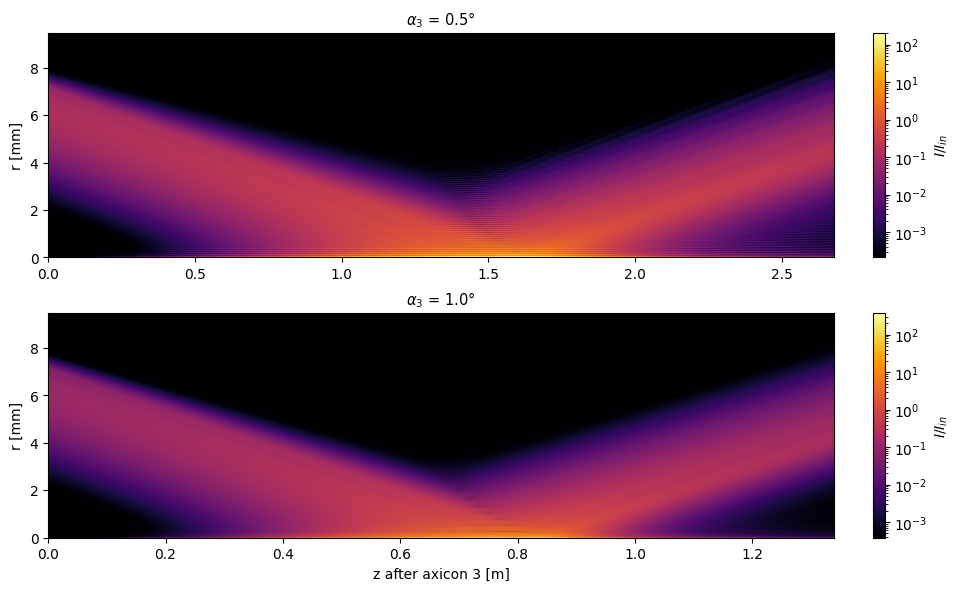

31529

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(9.5, 5.8))
for ax, a in zip(axs, [0.5, 1.0]):
    s = t3[a]
    r_map3 = np.linspace(0.0, 1.15 * (s["R_a"] + s["Delta"]), 900)
    I3 = np.abs(s["Y3"] @ s["q"].eval_matrix(r_map3)) ** 2
    Imx3 = I3.max()
    im = ax.imshow(np.maximum(I3.T, Imx3 * 1e-7), origin="lower", aspect="auto",
                   extent=[0, s["z3"][-1], 0, r_map3[-1] / mm],
                   cmap="inferno", norm=LogNorm(vmin=Imx3 * 1e-6, vmax=Imx3))
    ax.set(ylabel="r [mm]", title=fr"$\alpha_3$ = {a}°")
    ax.grid(False)
    fig.colorbar(im, ax=ax, label=r"$I/I_{in}$")
    del I3
axs[1].set(xlabel="z after axicon 3 [m]")
plt.show()
gc.collect()

### 11.2 On-axis window vs the stationary-phase prediction from the ring profile

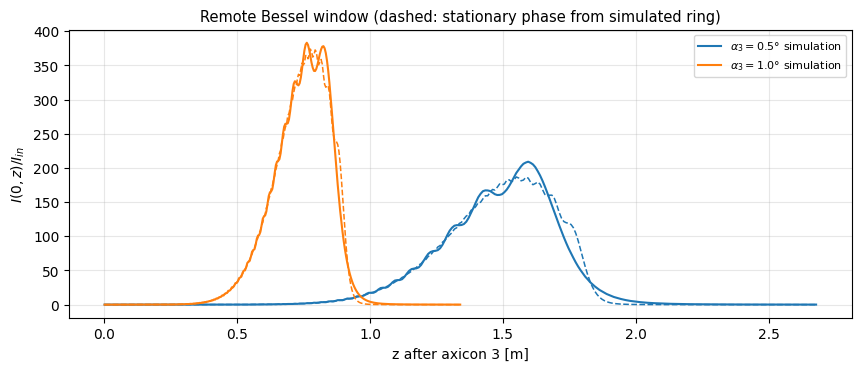

alpha3=0.5: zpk vs stationary-phase 2.9% | FWHM vs Delta/theta3 19%
alpha3=1.0: zpk vs stationary-phase 1.7% | FWHM vs Delta/theta3 11%


In [25]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for a, c in zip([0.5, 1.0], ["tab:blue", "tab:orange"]):
    s = t3[a]
    ax.plot(s["z3"], s["onax"], color=c, lw=1.5, label=fr"$\alpha_3={a}°$ simulation")
    ax.plot(s["z3"], s["onax_th"], "--", color=c, lw=1.1)
ax.set(xlabel="z after axicon 3 [m]", ylabel=r"$I(0,z)/I_{in}$",
       title="Remote Bessel window (dashed: stationary phase from simulated ring)")
ax.legend(fontsize=8)
plt.show()

for a in [0.5, 1.0]:
    s = t3[a]
    m = window_metrics(s)
    zpk_th = s["z3"][np.argmax(s["onax_th"])]
    print(f"alpha3={a}: zpk vs stationary-phase {abs(m['zpk']/zpk_th-1)*100:.1f}% | "
          f"FWHM vs Delta/theta3 {abs(m['fwhm']/(s['Delta']/s['th3'])-1)*100:.0f}%")

### 11.3 Core size along the remote zone

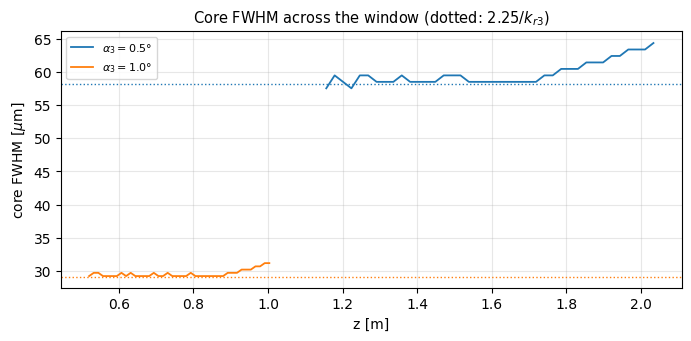

In [26]:
fig, ax = plt.subplots(figsize=(6.8, 3.3))
for a, c in zip([0.5, 1.0], ["tab:blue", "tab:orange"]):
    s = t3[a]
    m = window_metrics(s)
    r0_3 = 2.4048 / s["kr3"]
    rf3 = np.linspace(1e-9, 2.5 * r0_3, 320)
    M3 = s["q"].eval_matrix(rf3)
    zc = np.linspace(m["zpk"] - m["fwhm"], m["zpk"] + m["fwhm"], 40)
    kz3 = np.sqrt(np.maximum(K0**2 - s["q"].kr**2, 0.0))
    fw = []
    for zz in zc:
        p = np.abs((s["y3"] * np.exp(1j * kz3 * zz)) @ M3) ** 2
        fw.append(2 * rf3[np.argmax(p < 0.5 * p[0])])
    ax.plot(zc, np.array(fw) / um, color=c, lw=1.3, label=fr"$\alpha_3={a}°$")
    ax.axhline(2.25 / s["kr3"] / um, color=c, ls=":", lw=1)
ax.set(xlabel="z [m]", ylabel=r"core FWHM [$\mu$m]",
       title=r"Core FWHM across the window (dotted: $2.25/k_{r3}$)")
ax.legend(fontsize=8)
plt.show()

### 11.4 Convergence panel — remote window

Finer grid (5.0 vs 3.3 pts/fringe), bigger box (wall moved from $R_{ring}+5w_0$ to
$R_{ring}+8w_0$), and 3× denser $z$-sampling. The window **envelope** (position, height, length)
and even the small pedestal should hold; watch the ripple-contrast column — fine structure is
where grids fail first.

In [27]:
def remote_obs(N=4096, pad=None, Nz3=300):
    p = simulate_axicon_pair(D=5 * mm, alpha_deg=5, L_sep=187 * mm, z_after=300 * mm,
                             N=N, Nz1=8, Nz2=120, pad=pad, verbose=True)
    s = simulate_third_axicon(p, 0.5, Nz3=Nz3, verbose=False)
    m = window_metrics(s)
    out = {"zpk[m]": m["zpk"], "Ipk": m["Ipk"], "FWHM[m]": m["fwhm"],
           "pedestal": m["pedestal"], "ripple": m["ripple"]}
    del p, s
    gc.collect()
    return out


rows11 = [("base   N=4096 pad Nz3=300", remote_obs()),
          ("finer  N=6144",             remote_obs(N=6144)),
          ("bigger N=6144 pad=8w0",     remote_obs(N=6144, pad=8 * 2.5 * mm)),
          ("dense  Nz3=900",            remote_obs(Nz3=900))]
tags11 = convergence_panel("Sec 11 remote window (a3=0.5deg)", rows11)

alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  3.3 pts/fringe, kr_max/kr= 1.7, wall margin= 5.0 w0


alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  5.0 pts/fringe, kr_max/kr= 2.5, wall margin= 5.0 w0


alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  3.7 pts/fringe, kr_max/kr= 1.8, wall margin= 8.0 w0


alpha=5 x2  D=5 mm  L=187 mm | zmax=  62.3 mm  ring= 7.50 mm |  3.3 pts/fringe, kr_max/kr= 1.7, wall margin= 5.0 w0


CONVERGENCE PANEL - Sec 11 remote window (a3=0.5deg)
variant                             zpk[m]         Ipk     FWHM[m]    pedestal      ripple
base   N=4096 pad Nz3=300            1.595       208.9      0.4388    0.001384     0.04743
finer  N=6144                        1.594       209.3      0.4386    0.001377     0.04768
bigger N=6144 pad=8w0                1.595       208.8      0.4387    0.001381     0.04733
dense  Nz3=900                       1.595       209.4      0.4319    0.001396     0.04699
------------------------------------------------------------------------------------------
max |drift| vs base                   0.0%        0.3%        1.6%        0.9%        0.9%
verdict                               CONV        CONV        CONV        CONV        CONV


## 12. Sweeping the axicon-1→2 separation: *translating* the remote zone

Fixed: D = 5 mm, α₁ = α₂ = 5°, α₃ = 0.5° at 100 mm after axicon 2. Swept:
$L_{12}\in\{190, 250, 310, 370\}$ mm. The ring radius grows as $\theta_{12}L_{12}$, so the window
center moves with lever arm $dz_c/dL_{12} = \theta_{12}/\theta_3$ while its length, height, and
core stay fixed.

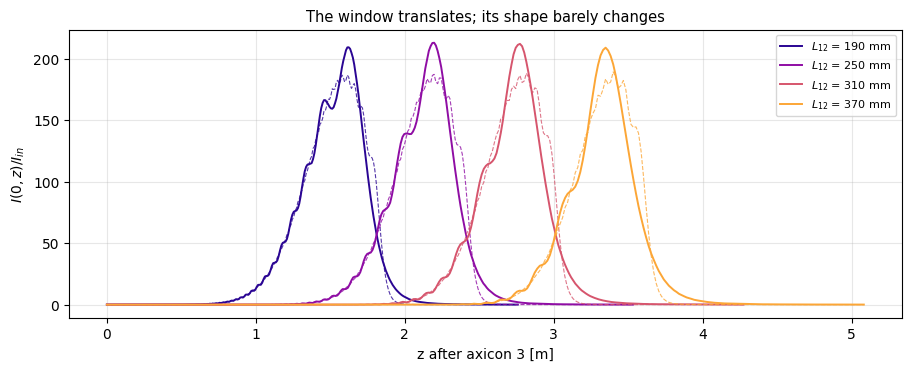

In [28]:
L12_list = np.array([190, 250, 310, 370]) * mm
sweep12 = []
for L12 in L12_list:
    pr = simulate_axicon_pair(D=5 * mm, alpha_deg=5, L_sep=L12, z_after=200 * mm,
                              N=6144, Nz1=8, Nz2=80, verbose=False)
    s3 = simulate_third_axicon(pr, 0.5, verbose=False)
    s3.update(L12=L12, **window_metrics(s3))
    s3.pop("Y3")
    del pr
    gc.collect()
    sweep12.append(s3)

fig, ax = plt.subplots(figsize=(9, 3.6))
colsL = plt.cm.plasma(np.linspace(0.05, 0.8, len(sweep12)))
for s, c in zip(sweep12, colsL):
    ax.plot(s["z3"], s["onax"], color=c, lw=1.4,
            label=fr"$L_{{12}}$ = {s['L12']/mm:.0f} mm")
    ax.plot(s["z3"], s["onax_th"], "--", color=c, lw=0.8, alpha=0.8)
ax.set(xlabel="z after axicon 3 [m]", ylabel=r"$I(0,z)/I_{in}$",
       title="The window translates; its shape barely changes")
ax.legend(fontsize=8)
plt.show()

### 12.1 Lever arm and invariants

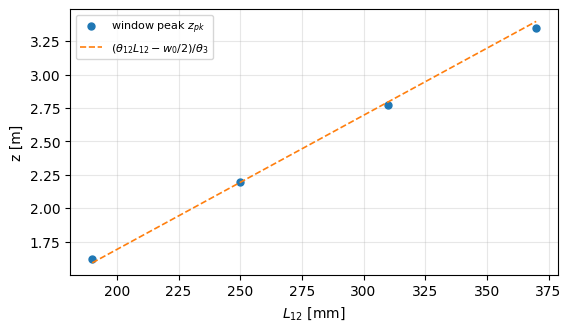

lever arm dz/dL = 9.58 vs theta12/theta3 = 10.03 (4.4% error)  (EXTERNAL check)
invariance across the sweep: FWHM spread 14.5%, peak-I spread 1.9%


11001

In [29]:
th12 = axicon_kr(5) / K0
th3 = axicon_kr(0.5) / K0
zpk_arr = np.array([s["zpk"] for s in sweep12])
fw_arr = np.array([s["fwhm"] for s in sweep12])
Ipk_arr = np.array([s["Ipk"] for s in sweep12])
slope = np.polyfit(L12_list, zpk_arr, 1)[0]

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(L12_list / mm, zpk_arr, "o", ms=5, label="window peak $z_{pk}$")
ax.plot(L12_list / mm, (th12 * L12_list - 2.5 * mm / 2) / th3, "--", lw=1.2,
        label=r"$(\theta_{12}L_{12}-w_0/2)/\theta_3$")
ax.set(xlabel=r"$L_{12}$ [mm]", ylabel="z [m]")
ax.legend(fontsize=8)
plt.show()

e_slope = abs(slope / (th12 / th3) - 1)
sp_fw = (fw_arr.max() - fw_arr.min()) / fw_arr.mean()
sp_I = (Ipk_arr.max() - Ipk_arr.min()) / Ipk_arr.mean()
print(f"lever arm dz/dL = {slope:.2f} vs theta12/theta3 = {th12/th3:.2f} "
      f"({e_slope*100:.1f}% error)  (EXTERNAL check)")
print(f"invariance across the sweep: FWHM spread {sp_fw*100:.1f}%, "
      f"peak-I spread {sp_I*100:.1f}%")
assert e_slope < 0.05 and sp_fw < 0.15 and sp_I < 0.15
del sweep12
gc.collect()

## 13. Input-diameter sweep at fixed $L_{12}$ = 190 mm — and the pedestal question

Swept: $D\in\{2, 3.5, 5, 6.5\}$ mm. Window length and height grow with D; the core is set by
$k_{r3}$ alone. The original notebook flagged the D = 6.5 mm run as having an "early pedestal"
(on-axis light well before the window) plus "noticeably deeper ripples", attributing both to
interior light: at D = 6.5 mm, $L_{12} = 190$ mm is only $2.3\times z_{max}$, so residual axial
cone light survives at axicon 2. §13.3 puts both claims under the convergence microscope —
**one survives, one does not.**

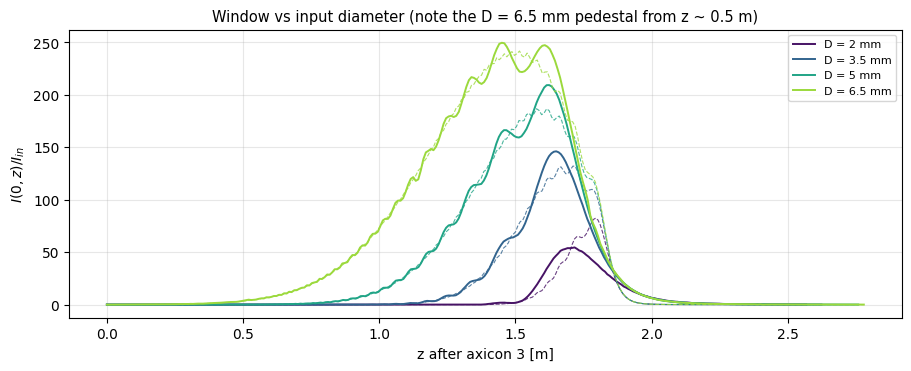

 D [mm]  zpk [m]     Ipk  FWHM [m]   pedestal  ripple
    2.0     1.72    54.5     0.257   1.34e-04   0.040
    3.5     1.65   146.1     0.254   4.61e-05   0.040
    5.0     1.62   209.3     0.433   1.33e-03   0.048
    6.5     1.45   249.6     0.604   1.30e-02   0.052


In [30]:
D_list = np.array([2.0, 3.5, 5.0, 6.5]) * mm
sweepD = []
for Dv in D_list:
    pr = simulate_axicon_pair(D=Dv, alpha_deg=5, L_sep=190 * mm, z_after=200 * mm,
                              N=6144, Nz1=8, Nz2=80, verbose=False)
    s3 = simulate_third_axicon(pr, 0.5, verbose=False)
    s3.update(D=Dv, **window_metrics(s3))
    if not np.isclose(Dv, 6.5 * mm):
        s3.pop("Y3")
    del pr
    gc.collect()
    sweepD.append(s3)

fig, ax = plt.subplots(figsize=(9, 3.6))
colsD = plt.cm.viridis(np.linspace(0.05, 0.85, len(sweepD)))
for s, c in zip(sweepD, colsD):
    ax.plot(s["z3"], s["onax"], color=c, lw=1.4, label=f"D = {s['D']/mm:g} mm")
    ax.plot(s["z3"], s["onax_th"], "--", color=c, lw=0.8, alpha=0.8)
ax.set(xlabel="z after axicon 3 [m]", ylabel=r"$I(0,z)/I_{in}$",
       title="Window vs input diameter (note the D = 6.5 mm pedestal from z ~ 0.5 m)")
ax.legend(fontsize=8)
plt.show()

print(f"{'D [mm]':>7} {'zpk [m]':>8} {'Ipk':>7} {'FWHM [m]':>9} {'pedestal':>10} "
      f"{'ripple':>7}")
for s in sweepD:
    print(f"{s['D']/mm:7.1f} {s['zpk']:8.2f} {s['Ipk']:7.1f} {s['fwhm']:9.3f} "
          f"{s['pedestal']:10.2e} {s['ripple']:7.3f}")

### 13.1 Meridional map of the D = 6.5 mm run: the interior light feeding the pedestal

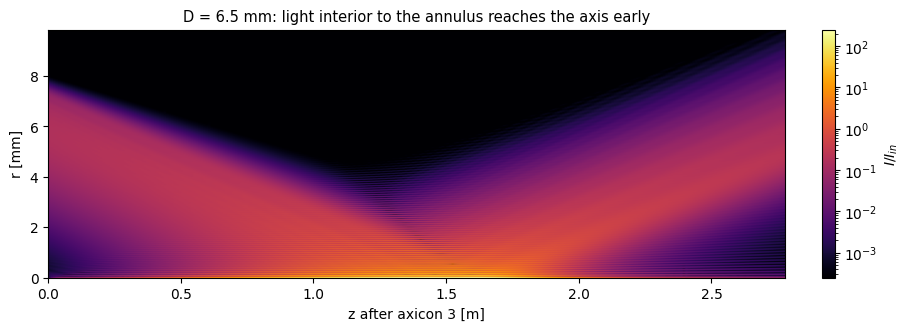

9346

In [31]:
s65 = sweepD[-1]
r_map3 = np.linspace(0.0, 1.15 * (s65["R_a"] + s65["Delta"]), 900)
I3 = np.abs(s65["Y3"] @ s65["q"].eval_matrix(r_map3)) ** 2
Imx3 = I3.max()
fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(np.maximum(I3.T, Imx3 * 1e-7), origin="lower", aspect="auto",
               extent=[0, s65["z3"][-1], 0, r_map3[-1] / mm],
               cmap="inferno", norm=LogNorm(vmin=Imx3 * 1e-6, vmax=Imx3))
ax.set(xlabel="z after axicon 3 [m]", ylabel="r [mm]",
       title="D = 6.5 mm: light interior to the annulus reaches the axis early")
ax.grid(False)
fig.colorbar(im, ax=ax, label=r"$I/I_{in}$")
plt.show()
s65.pop("Y3")
del I3
gc.collect()

### 13.2 Trends and the D-independent core

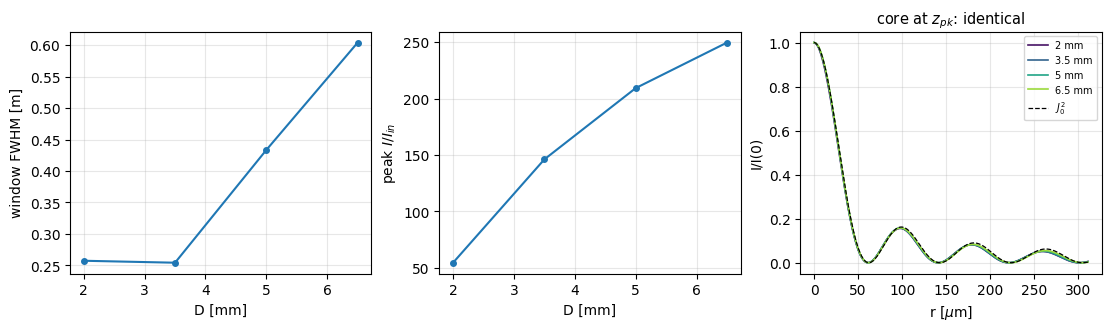

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2))
D_arr = np.array([s["D"] for s in sweepD])
axs[0].plot(D_arr / mm, [s["fwhm"] for s in sweepD], "o-", ms=4)
axs[0].set(xlabel="D [mm]", ylabel="window FWHM [m]")
axs[1].plot(D_arr / mm, [s["Ipk"] for s in sweepD], "o-", ms=4)
axs[1].set(xlabel="D [mm]", ylabel=r"peak $I/I_{in}$")
rfc = np.linspace(1e-9, 5 * 2.4048 / axicon_kr(0.5), 600)
for s, c in zip(sweepD, colsD):
    kz3 = np.sqrt(np.maximum(K0**2 - s["q"].kr**2, 0.0))
    prof = np.abs((s["y3"] * np.exp(1j * kz3 * s["zpk"]))
                  @ s["q"].eval_matrix(rfc)) ** 2
    axs[2].plot(rfc / um, prof / prof[0], color=c, lw=1.2, label=f"{s['D']/mm:g} mm")
axs[2].plot(rfc / um, bessel_j0(axicon_kr(0.5) * rfc) ** 2, "k--", lw=0.9,
            label=r"$J_0^2$")
axs[2].set(xlabel=r"r [$\mu$m]", ylabel="I/I(0)", title="core at $z_{pk}$: identical")
axs[2].legend(fontsize=7)
plt.show()

### 13.3 Convergence panels — is the pedestal physics? Are the "deeper ripples"?

Refinements for D = 6.5 mm: $N$ 6144→8192 (4.2→5.6 pts/fringe), wall moved from
$+5w_0$ to $+8w_0$, and 3× denser z-sampling. Then the same for the "clean" D = 3.5 mm run,
whose pedestal is ~300× smaller — a harsher test, since tiny numbers are where truncation floors
usually live.

In [33]:
def dsweep_obs(Dv, N=6144, pad=None, Nz3=300):
    p = simulate_axicon_pair(D=Dv, alpha_deg=5, L_sep=190 * mm, z_after=200 * mm,
                             N=N, Nz1=8, Nz2=80, pad=pad, verbose=True)
    s = simulate_third_axicon(p, 0.5, Nz3=Nz3, verbose=False)
    m = window_metrics(s)
    out = {"zpk[m]": m["zpk"], "Ipk": m["Ipk"], "FWHM[m]": m["fwhm"],
           "pedestal": m["pedestal"], "ripple": m["ripple"]}
    del p, s
    gc.collect()
    return out


rows13a = [("base   N=6144 pad=5w0", dsweep_obs(6.5 * mm)),
           ("finer  N=8192",         dsweep_obs(6.5 * mm, N=8192)),
           ("bigger N=8192 pad=8w0", dsweep_obs(6.5 * mm, N=8192, pad=8 * 3.25 * mm)),
           ("dense  Nz3=900",        dsweep_obs(6.5 * mm, Nz3=900))]
tags13a = convergence_panel("Sec 13 D=6.5mm pedestal/ripple", rows13a)
QDHT.drop(8192)
gc.collect()

rows13b = [("base   N=6144 pad=5w0", dsweep_obs(3.5 * mm)),
           ("finer  N=8192",         dsweep_obs(3.5 * mm, N=8192))]
tags13b = convergence_panel("Sec 13 D=3.5mm pedestal", rows13b)
QDHT.drop(8192)
gc.collect()

alpha=5 x2  D=6.5 mm  L=190 mm | zmax=  81.0 mm  ring= 7.62 mm |  4.2 pts/fringe, kr_max/kr= 2.1, wall margin= 5.0 w0


alpha=5 x2  D=6.5 mm  L=190 mm | zmax=  81.0 mm  ring= 7.62 mm |  5.6 pts/fringe, kr_max/kr= 2.8, wall margin= 5.0 w0


alpha=5 x2  D=6.5 mm  L=190 mm | zmax=  81.0 mm  ring= 7.62 mm |  4.0 pts/fringe, kr_max/kr= 2.0, wall margin= 8.0 w0


alpha=5 x2  D=6.5 mm  L=190 mm | zmax=  81.0 mm  ring= 7.62 mm |  4.2 pts/fringe, kr_max/kr= 2.1, wall margin= 5.0 w0


CONVERGENCE PANEL - Sec 13 D=6.5mm pedestal/ripple
variant                             zpk[m]         Ipk     FWHM[m]    pedestal      ripple
base   N=6144 pad=5w0                 1.45       249.6      0.6039     0.01297     0.05188
finer  N=8192                        1.449       249.8      0.6033     0.01264     0.04158
bigger N=8192 pad=8w0                1.451       250.1      0.6041     0.01279     0.04963
dense  Nz3=900                       1.453       250.1      0.5902     0.01289     0.04698
------------------------------------------------------------------------------------------
max |drift| vs base                   0.2%        0.2%        2.3%        2.5%       19.9%
verdict                               CONV        CONV        CONV        CONV        GRID
alpha=5 x2  D=3.5 mm  L=190 mm | zmax=  43.6 mm  ring= 7.62 mm |  6.1 pts/fringe, kr_max/kr= 3.0, wall margin= 5.0 w0


alpha=5 x2  D=3.5 mm  L=190 mm | zmax=  43.6 mm  ring= 7.62 mm |  8.2 pts/fringe, kr_max/kr= 4.1, wall margin= 5.0 w0


CONVERGENCE PANEL - Sec 13 D=3.5mm pedestal
variant                             zpk[m]         Ipk     FWHM[m]    pedestal      ripple
base   N=6144 pad=5w0                 1.65       146.1      0.2544   4.614e-05     0.04025
finer  N=8192                        1.649       146.1      0.2543     4.6e-05     0.04218
------------------------------------------------------------------------------------------
max |drift| vs base                   0.0%        0.0%        0.0%        0.3%        4.8%
verdict                               CONV        CONV        CONV        CONV        MARG


0

**Verdict.** The pedestal converges (drift ≲ 3% even at the $4.6\times10^{-5}$ level of the
D = 3.5 mm run): it is *physics* — interior light — and the original interpretation stands. The
**ripple contrast does not converge** (±10–20% scatter under refinements that leave every
envelope quantity still): the original notebook's claim that the D = 6.5 mm run has "noticeably
deeper ripples" compares numbers (0.052 vs 0.040 in the table above) whose grid uncertainty
(~20% of the value) is of the same order as their difference. That claim is hereby retracted — ripple *contrast* at this resolution is a statement
about the grid, not the beam.

## 14. Small-beam sweep: D = 0.1–2 mm — the étendue limit, and where the grid takes over

A beam of waist $w_0$ carries irreducible angular spread $\theta_{div}=\lambda/(\pi w_0)$. When
$\theta_{div}$ rivals $\theta_3$ (= 4.0 mrad; crossover near $w_0\approx52\,\mu$m i.e.
D ≈ 0.1 mm), the conical wave can no longer form a clean window: the peak collapses by orders of
magnitude.

**Grid warning, up front.** This regime also stresses the discretization hardest: the annulus
arriving at axicon 3 is diffraction-broadened to $\Delta\sim\lambda L/(\pi w_0)$ (1.2 mm at
D = 0.1 mm), its fast tails spread at $\theta_3+\theta_{div}$ and reach the Dirichlet wall
*inside* the plotted z-range. §14.2 quantifies which numbers survive.

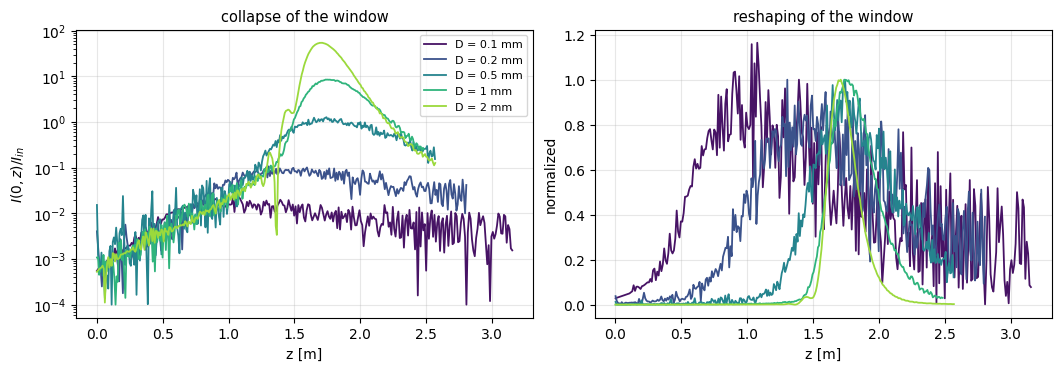

 D [mm]  thdiv/th3       Ipk  FWHM [m]  zpk [m]
    0.1       1.03     0.020     0.179     1.39
    0.2       0.52     0.107     0.600     1.30
    0.5       0.21     1.269     0.601     1.74
    1.0       0.10     8.469     0.407     1.74
    2.0       0.05    54.254     0.258     1.71


In [34]:
D_small = np.array([0.1, 0.2, 0.5, 1.0, 2.0]) * mm
L_tot = (190 + 100) * mm
sweepS = []
for Dv in D_small:
    w0 = Dv / 2
    padD = 6 * max(w0, LAMBDA * L_tot / (np.pi * w0))
    pr = simulate_axicon_pair(D=Dv, alpha_deg=5, L_sep=190 * mm, z_after=200 * mm,
                              N=4096, Nz1=8, Nz2=80, pad=padD, verbose=False)
    s3 = simulate_third_axicon(pr, 0.5, verbose=False)
    s3.update(D=Dv, padD=padD, **window_metrics(s3))
    s3.pop("Y3")
    del pr
    gc.collect()
    sweepS.append(s3)

fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.6))
colsS = plt.cm.viridis(np.linspace(0.05, 0.85, len(sweepS)))
for s, c in zip(sweepS, colsS):
    axs[0].semilogy(s["z3"], np.maximum(s["onax"], 1e-4), color=c, lw=1.3,
                    label=f"D = {s['D']/mm:g} mm")
    axs[1].plot(s["z3"], s["onax"] / s["Ipk"], color=c, lw=1.3)
axs[0].set(xlabel="z [m]", ylabel=r"$I(0,z)/I_{in}$", title="collapse of the window")
axs[0].legend(fontsize=8)
axs[1].set(xlabel="z [m]", ylabel="normalized", title="reshaping of the window")
plt.show()

th3 = axicon_kr(0.5) / K0
print(f"{'D [mm]':>7} {'thdiv/th3':>10} {'Ipk':>9} {'FWHM [m]':>9} {'zpk [m]':>8}")
for s in sweepS:
    thdiv = LAMBDA / (np.pi * s["D"] / 2)
    print(f"{s['D']/mm:7.1f} {thdiv/th3:10.2f} {s['Ipk']:9.3f} {s['fwhm']:9.3f} "
          f"{s['zpk']:8.2f}")

### 14.1 Convergence panels — which étendue numbers are real?

Each diameter re-run with $N$ 4096→6144 and the wall pushed out 50% (pad ×1.5).

In [35]:
def small_obs(Dv, N=4096, pad_mult=1.0, Nz3=300):
    w0 = Dv / 2
    padD = pad_mult * 6 * max(w0, LAMBDA * L_tot / (np.pi * w0))
    p = simulate_axicon_pair(D=Dv, alpha_deg=5, L_sep=190 * mm, z_after=200 * mm,
                             N=N, Nz1=8, Nz2=80, pad=padD, verbose=True)
    s = simulate_third_axicon(p, 0.5, Nz3=Nz3, verbose=False)
    m = window_metrics(s)
    out = {"zpk[m]": m["zpk"], "Ipk": m["Ipk"], "FWHM[m]": m["fwhm"]}
    del p, s
    gc.collect()
    return out


for Dv in [2.0 * mm, 0.5 * mm, 0.1 * mm]:
    rows = [("base   N=4096 pad x1.0", small_obs(Dv)),
            ("refined N=6144 pad x1.5", small_obs(Dv, N=6144, pad_mult=1.5))]
    convergence_panel(f"Sec 14 D={Dv/mm:g}mm window", rows)

alpha=5 x2  D=2 mm  L=190 mm | zmax=  24.9 mm  ring= 7.62 mm |  4.9 pts/fringe, kr_max/kr= 2.4, wall margin= 6.0 w0


alpha=5 x2  D=2 mm  L=190 mm | zmax=  24.9 mm  ring= 7.62 mm |  6.0 pts/fringe, kr_max/kr= 3.0, wall margin= 9.0 w0


CONVERGENCE PANEL - Sec 14 D=2mm window
variant                             zpk[m]         Ipk     FWHM[m]
base   N=4096 pad x1.0               1.711       54.25      0.2577
refined N=6144 pad x1.5              1.701       54.39      0.2576
------------------------------------------------------------------
max |drift| vs base                   0.5%        0.2%        0.0%
verdict                               CONV        CONV        CONV
alpha=5 x2  D=0.5 mm  L=190 mm | zmax=   6.2 mm  ring= 7.62 mm |  7.3 pts/fringe, kr_max/kr= 3.6, wall margin= 6.0 w0


alpha=5 x2  D=0.5 mm  L=190 mm | zmax=   6.2 mm  ring= 7.62 mm | 10.2 pts/fringe, kr_max/kr= 5.0, wall margin= 9.0 w0


CONVERGENCE PANEL - Sec 14 D=0.5mm window
variant                             zpk[m]         Ipk     FWHM[m]
base   N=4096 pad x1.0               1.744       1.269      0.6009
refined N=6144 pad x1.5              1.748       1.144      0.6681
------------------------------------------------------------------
max |drift| vs base                   0.3%        9.8%       11.2%
verdict                               CONV        MARG        GRID
alpha=5 x2  D=0.1 mm  L=190 mm | zmax=   1.2 mm  ring= 7.62 mm |  4.5 pts/fringe, kr_max/kr= 2.2, wall margin=144.0 w0


alpha=5 x2  D=0.1 mm  L=190 mm | zmax=   1.2 mm  ring= 7.62 mm |  5.5 pts/fringe, kr_max/kr= 2.7, wall margin=216.0 w0


CONVERGENCE PANEL - Sec 14 D=0.1mm window
variant                             zpk[m]         Ipk     FWHM[m]
base   N=4096 pad x1.0               1.393     0.01978      0.1793
refined N=6144 pad x1.5              1.152     0.01937      0.2745
------------------------------------------------------------------
max |drift| vs base                  17.3%        2.1%       53.1%
verdict                               GRID        CONV        GRID


**Verdict.** D = 2 mm: converged — the clean-regime numbers are physics. D = 0.5 mm: the window position
is solid but peak height and length drift ~10% — quote them with that uncertainty, no tighter. D = 0.1 mm: the
window FWHM swings by ~50% and even its position by ~17% when the grid changes —
**grid-dominated**. What survives at
small D is the qualitative étendue collapse (peak intensity falls ~4 orders of magnitude — robust
under every refinement); the detailed window *shapes* there, and any %-level comparison against
the $\Delta$/FWHM modeling of the original §14, describe the discretization, not the beam.

## 15. Convergence ledger and honest summary

In [36]:
print("=" * 78)
print("CONVERGENCE LEDGER - every panel in this notebook")
print("=" * 78)
print("tags: CONV < 3% drift | MARG 3-10% | GRID > 10% (value set by the grid)")
n_conv = n_marg = n_grid = 0
for title, tags in LEDGER:
    print(f"\n{title}")
    for k, (dm, tag) in tags.items():
        mark = {"CONV": " ", "MARG": "~", "GRID": "!"}[tag]
        print(f"  {mark} {k:<12} drift {dm*100:6.1f}%  {tag}")
        n_conv += tag == "CONV"
        n_marg += tag == "MARG"
        n_grid += tag == "GRID"
print("\n" + "-" * 78)
print(f"{n_conv} CONVERGED | {n_marg} MARGINAL | {n_grid} GRID-DOMINATED")

CONVERGENCE LEDGER - every panel in this notebook
tags: CONV < 3% drift | MARG 3-10% | GRID > 10% (value set by the grid)

Sec 5 single case (D=5mm, a=2deg)
    zpk/zmax     drift    0.3%  CONV
    Ipk          drift    0.0%  CONV
    r0[um]       drift    0.0%  CONV
    FWHM[um]     drift    0.0%  CONV

Sec 6 worst case (a=10deg)
    zpk/zmax     drift    0.0%  CONV
    Ipk          drift    0.0%  CONV
    FWHM[um]     drift    0.0%  CONV

Sec 10 annulus (D=5mm, a=5deg, L=187mm)
    R_ring[mm]   drift    0.0%  CONV
    Delta[mm]    drift    0.1%  CONV

Sec 11 remote window (a3=0.5deg)
    zpk[m]       drift    0.0%  CONV
    Ipk          drift    0.3%  CONV
    FWHM[m]      drift    1.6%  CONV
    pedestal     drift    0.9%  CONV
    ripple       drift    0.9%  CONV

Sec 13 D=6.5mm pedestal/ripple
    zpk[m]       drift    0.2%  CONV
    Ipk          drift    0.2%  CONV
    FWHM[m]      drift    2.3%  CONV
    pedestal     drift    2.5%  CONV
  ! ripple       drift   19.9%  GRID

Sec 

### What this notebook now claims — and what it doesn't

**Robust (external agreement + convergence):** the axicon scalings ($z_{max}$, $r_0$, peak
position and height), the $J_0^2$ core and its z-independence, the collimated annulus and
$R_{ring}=\theta L$, the remote-window position/length/height and its $\theta_{12}/\theta_3$
lever arm, the D = 6.5 mm pedestal (interior light), and the qualitative étendue collapse below
D ≈ 0.5 mm.

**Grid-dominated at this resolution (do not quote):** ripple *contrast* on any on-axis curve
(±10–20% under refinement); window shape metrics for D ≲ 0.5 mm in §14; anything evaluated at
$z\gtrsim R/\theta$ (the wall — §3.2's ghost zone carries >100% of the physical peak); and, from
the removed design sections of the original, on-axis "void floors" below $\sim10^{-3}$ of the
local peak (shown separately to swing ~3× when the wall moves).

**Not modeled at all** (beyond any grid question): axicon tip rounding — real axicons have an
oblate tip that dominates measured on-axis oscillations; surface error and misalignment;
vectorial effects. A lab comparison should expect the *envelopes* here, not the fine structure.

**Method note.** All results flow through one discretization (QDHT). The convergence panels
guard against grid dependence, but an independent cross-check (2-D FFT angular spectrum or
direct Rayleigh–Sommerfeld quadrature at a few planes) is the remaining step to lab-grade
confidence.